# 📈 Plotly — Interactive Charts for ML Results

> **What you'll learn:** how to build interactive charts (hover, zoom, facets, animation, sliders) with Plotly Express and Graph Objects, export them as HTML pages or static images, and turn model-evaluation results into a small interactive dashboard with a decision-threshold slider.

> 🧭 **Optional notebook.** Matplotlib and Seaborn cover everything the rest of the course needs. Do this notebook if you want to share *interactive* results with teammates or stakeholders — or skim it and come back later.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate (one 🔴 section on sliders and buttons) |
| **Time** | ~2 hours to read and run, +1 hour for exercises and the project |
| **Prerequisites** | [Matplotlib and Seaborn](01_Matplotlib_and_Seaborn.ipynb) (figures, axes, choosing a chart), [Pandas](../01_Core_Scientific_Computing/02_Pandas.ipynb) (groupby, melt) |
| **Tested with** | Python 3.12 · plotly 7.0 · kaleido 1.4 (static images) · pandas 3.0 · scikit-learn 1.9 |
| **Interview relevance** | ⭐ Low–Medium — rarely a coding topic on its own, but "how would you present model results / pick a threshold with stakeholders?" and dashboard design come up in ML and data-science rounds |

## 🤔 What Is Plotly?

A Matplotlib chart is like a **printed photo**: what you see is what you get. A Plotly chart is like a **map app on your phone**: you can hover over a point to read its exact value, zoom into a corner, hide a group by clicking its legend entry, or press ▶ to watch it change over time.

**Plotly** is a Python library that describes a chart as plain data (a *figure*: a list of **traces** — the drawn data series — plus a **layout** — titles, axes, legend) and hands that description to **plotly.js**, a JavaScript library that draws it in a web browser or notebook.

```
 Python (you)                         Browser / notebook
 ────────────                         ──────────────────
 px.scatter(df, x=…, y=…)  ──JSON──▶  plotly.js draws an interactive chart
       │
       └── fig.write_image()  ──▶  kaleido + headless Chrome  ──▶  PNG / SVG / PDF
```

It has two layers:
- **Plotly Express (`px`)** — one function call per chart, straight from a tidy DataFrame (like Seaborn).
- **Graph Objects (`go`)** — build a figure trace by trace with full control (like Matplotlib's object API).

## 🎯 Why It Matters

- **Exploring results.** When a model has thousands of predictions, hovering to find *which* rows are the outliers is much faster than re-plotting.
- **Sharing with non-programmers.** One `write_html` call gives a self-contained web page a product manager can open, zoom, and filter — no Python needed.
- **Dashboards.** Plotly is the charting engine behind **Dash**, and works inside **Streamlit**, Gradio, Jupyter, and VS Code — common tools for internal ML dashboards.
- **Decision making.** Choosing a classification threshold, comparing experiments, or monitoring drift are all easier with a slider than with twenty static images.
- **In interviews** you will rarely be asked to write Plotly code, but you *will* be asked how you'd **communicate model results**, how you'd **pick a threshold** with a business partner, or to **design a monitoring dashboard**. The mini project here is a concrete story you can tell.

## ✅ By the End You Can

- [ ] Explain what a Plotly figure is (traces + layout as JSON) and when to use `px` vs `go`
- [ ] Build the core charts with hover labels, facets, animation frames, and subplots
- [ ] Style figures with layouts and templates, and avoid the classic "raw rows in a bar chart" bug
- [ ] Export interactive HTML and static PNG/SVG/PDF — and make notebook charts visible on GitHub
- [ ] Add dropdowns and sliders, and build a model-comparison dashboard with a threshold slider

## 📋 Table of Contents

1. [Your First Interactive Chart](#1.-Your-First-Interactive-Chart-🟢)
2. [Figures Are Just Data: Express vs Graph Objects](#2.-Figures-Are-Just-Data:-Express-vs-Graph-Objects-🟢)
3. [Core Chart Types](#3.-Core-Chart-Types-🟢)
4. [Hover Labels, Colors, and Facets](#4.-Hover-Labels,-Colors,-and-Facets-🟡)
5. [Animation Frames](#5.-Animation-Frames-🟡)
6. [Subplots with `make_subplots`](#6.-Subplots-with-make_subplots-🟡)
7. [Layout, Templates, and Styling](#7.-Layout,-Templates,-and-Styling-🟢)
8. [Maps](#8.-Maps-🟡)
9. [Renderers and Exporting: HTML and Static Images](#9.-Renderers-and-Exporting:-HTML-and-Static-Images-🟢)
10. [Buttons and Sliders](#10.-Buttons-and-Sliders-🔴)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Interactive-Model-Comparison-Dashboard) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

**About static images.** Interactive Plotly charts are drawn by JavaScript, and **GitHub's notebook viewer does not run JavaScript** — so a notebook saved with only interactive output shows *empty* space on GitHub. The setup cell therefore sets the renderer to `"plotly_mimetype+png"`:
- `plotly_mimetype` → the interactive chart you see in JupyterLab, Jupyter Notebook 7, and VS Code;
- `png` → a static snapshot stored next to it in the `.ipynb` file, which GitHub displays.

Making the PNG uses **kaleido**, which drives a headless Google Chrome. If Chrome is not found, the cell tells you and keeps charts interactive-only (run `plotly_get_chrome` in a terminal to fix it). On Google Colab, Colab's own renderer is kept.

The `check()` helper gives instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

In [1]:
# %pip install -q "plotly>=6" "kaleido>=1" "pandas>=2.2" "scikit-learn>=1.5"

import json
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

print(f"Python {sys.version.split()[0]} | plotly {plotly.__version__} (plotly.js {plotly.offline.get_plotlyjs_version()}) | pandas {pd.__version__}")

rng = np.random.default_rng(42)
OUTPUT_DIR = Path("_outputs")                  # files we write go here (ignored by git)
OUTPUT_DIR.mkdir(exist_ok=True)

# Can we make static images? (kaleido needs a Chrome/Chromium browser on this machine)
try:
    px.scatter(x=[0, 1], y=[0, 1]).to_image(format="png", width=100, height=100)
    STATIC_OK = True
except Exception as err:                       # noqa: BLE001 — report the real reason
    STATIC_OK = False
    print(f"⚠️ Static image export unavailable ({type(err).__name__}: {str(err)[:100]}).")
    print("   Charts stay interactive. To enable PNG snapshots run `plotly_get_chrome` in a terminal, then restart.")

if "google.colab" in sys.modules:
    pio.renderers.default = "colab"
else:
    pio.renderers.default = "plotly_mimetype+png" if STATIC_OK else "plotly_mimetype"
print("static export:", STATIC_OK, "| renderer:", pio.renderers.default)


def check(name, got, expected, hint=""):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    try:                                       # numbers / arrays: compare shape and values
        g, e = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        ok = g.shape == e.shape and np.allclose(g, e)
    except (TypeError, ValueError):            # strings, mixed lists: exact equality
        ok = got == expected
    assert ok, f"❌ {name}: got {got!r}. {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | plotly 7.0.0 (plotly.js 4.0.0) | pandas 3.0.5


static export: True | renderer: plotly_mimetype+png


## 1. Your First Interactive Chart 🟢

We'll use **Gapminder** — real life-expectancy, population, and GDP figures for 142 countries every 5 years from 1952 to 2007. It ships *inside* the plotly package (`px.data`), so no download is needed.

The one rule of Plotly Express: **one row per point, one column per property**. You name columns; `px` maps them to position, color, size, and hover text.

In [2]:
gapminder = px.data.gapminder()               # bundled CSV → pandas DataFrame
print(gapminder.shape, "| years:", sorted(gapminder["year"].unique().tolist()))
gapminder.head()

(1704, 8) | years: [1952, 1957, 1962, 1967, 1972, 1977, 1982, 1987, 1992, 1997, 2002, 2007]


,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


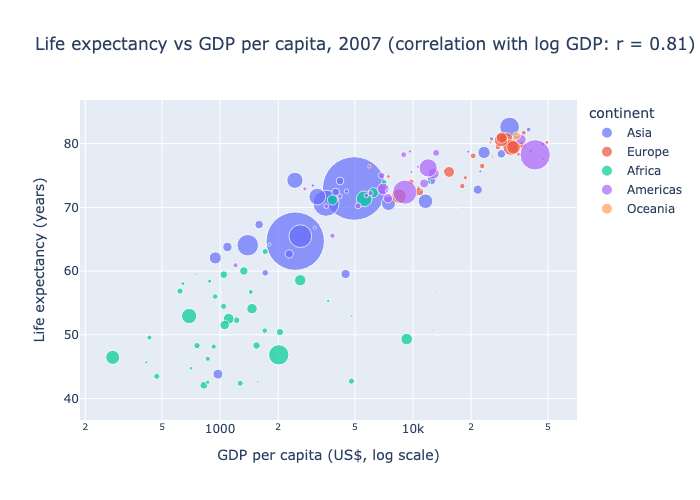

In [3]:
gap2007 = gapminder[gapminder["year"] == 2007]
r_log_gdp = np.corrcoef(np.log10(gap2007["gdpPercap"]), gap2007["lifeExp"])[0, 1]

fig = px.scatter(
    gap2007,
    x="gdpPercap", y="lifeExp",
    size="pop", color="continent",           # bubble size = population, color = continent
    hover_name="country",                    # bold title of the hover box
    log_x=True, size_max=45,
    labels={"gdpPercap": "GDP per capita (US$, log scale)", "lifeExp": "Life expectancy (years)", "pop": "Population"},
    title=f"Life expectancy vs GDP per capita, 2007 (correlation with log GDP: r = {r_log_gdp:.2f})",
)
fig.show()

Try it (in Jupyter or VS Code): **hover** a bubble, **drag** a box to zoom, **double-click** to reset, **click** a continent in the legend to hide it, double-click it to isolate it. The toolbar's camera icon downloads a PNG.

Why `log_x=True`? GDP per capita spans from a few hundred to ~50,000 dollars. On a linear axis most countries would be squashed against the left edge; on a log axis each step (1k → 10k → 100k) gets the same space.

### ✍️ Your Turn

Using `europe_2007`, make `fig_europe`: a scatter of **population (`pop`) on a log x-axis** vs **life expectancy**, with the **country name** in the hover box.

In [4]:
europe_2007 = gap2007[gap2007["continent"] == "Europe"]
fig_europe = None  # TODO: px.scatter(...)
check("europe_scatter",
      None if fig_europe is None else [len(fig_europe.data[0].x), fig_europe.layout.xaxis.type, fig_europe.data[0].hovertext is not None],
      [len(europe_2007), "log", True],
      hint="px.scatter(europe_2007, x='pop', y='lifeExp', hover_name='country', log_x=True)")

⏳ europe_scatter: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
europe_2007 = gap2007[gap2007["continent"] == "Europe"]
fig_europe = px.scatter(europe_2007, x="pop", y="lifeExp", hover_name="country", log_x=True)
check("europe_scatter",
      [len(fig_europe.data[0].x), fig_europe.layout.xaxis.type, fig_europe.data[0].hovertext is not None],
      [len(europe_2007), "log", True])
```
</details>

> 💡 **Interview angle:** "When would you choose Plotly over Matplotlib?" — when people need to *explore* the result (hover, zoom, filter) or you are shipping it in a web page or dashboard. For papers, slide decks, and quick EDA, static Matplotlib/Seaborn is simpler and lighter.

## 2. Figures Are Just Data: Express vs Graph Objects 🟢

Every Plotly chart — however it was made — is a **`go.Figure`** holding:

| Part | What it is | Example |
|---|---|---|
| `fig.data` | a tuple of **traces** (one drawn series each) | `Scatter(x=…, y=…, mode="markers", name="Asia")` |
| `fig.layout` | everything that is not data | title, axes, legend, size, sliders |
| `fig.frames` | optional animation frames | one frame per year |

Plotly Express is a **shortcut that builds this object for you** — for example, one trace per color group.

In [5]:
fig = px.scatter(gap2007, x="gdpPercap", y="lifeExp", color="continent", log_x=True)

print("number of traces:", len(fig.data), "→", [trace.name for trace in fig.data])
print("trace 0:", fig.data[0].type, "| mode:", fig.data[0].mode, "| points:", len(fig.data[0].x))
print("x-axis type:", fig.layout.xaxis.type)
print("top-level keys of the JSON spec:", list(fig.to_dict().keys()))
print(f"JSON size: {len(fig.to_json()) / 1024:.1f} KB")

number of traces: 5 → ['Asia', 'Europe', 'Africa', 'Americas', 'Oceania']
trace 0: scatter | mode: markers | points: 33
x-axis type: log
top-level keys of the JSON spec: ['data', 'layout']
JSON size: 11.5 KB


The same chart with **Graph Objects**: more lines, but you control every trace. This is how you build things `px` has no function for (mixed chart types, custom hover text, dashboards).

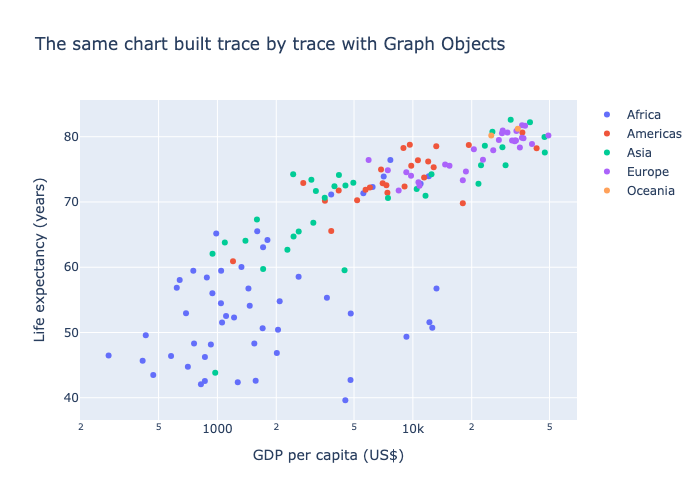

In [6]:
fig_go = go.Figure()
for continent, group in gap2007.groupby("continent"):
    fig_go.add_trace(go.Scatter(
        x=group["gdpPercap"], y=group["lifeExp"], mode="markers", name=continent,
        text=group["country"],
        hovertemplate="<b>%{text}</b><br>GDP per capita: %{x:$,.0f}<br>Life expectancy: %{y:.1f}<extra></extra>",
    ))
fig_go.update_layout(
    title="The same chart built trace by trace with Graph Objects",
    xaxis_type="log", xaxis_title="GDP per capita (US$)", yaxis_title="Life expectancy (years)",
)
fig_go.show()

| | Plotly Express `px` | Graph Objects `go` |
|---|---|---|
| Input | tidy DataFrame + column names | arrays / lists per trace |
| Code | one call | `go.Figure()` + `add_trace` + `update_layout` |
| Best for | 90% of charts, fast exploration | custom dashboards, mixed trace types, fine control |
| Mix them? | Yes — every `px` figure is a `go.Figure`, so you can call `add_trace` / `update_layout` on it | |

`update_layout(xaxis_type="log")` uses **magic underscores**: `xaxis_type` is short for `layout.xaxis.type`.

### ✍️ Your Turn

With **Graph Objects** (not `px`), make `fig_bar_go`: a single `go.Bar` trace with continents on the x-axis and `continent_mean` (mean life expectancy in 2007) on the y-axis.

In [7]:
continent_mean = gap2007.groupby("continent")["lifeExp"].mean().round(1)
fig_bar_go = None  # TODO: go.Figure(go.Bar(...))
check("go_bar_type_and_x",
      None if fig_bar_go is None else [fig_bar_go.data[0].type, [str(v) for v in fig_bar_go.data[0].x]],
      ["bar", continent_mean.index.tolist()],
      hint="go.Figure(go.Bar(x=continent_mean.index, y=continent_mean.values))")
check("go_bar_y", None if fig_bar_go is None else list(fig_bar_go.data[0].y), continent_mean.tolist())

⏳ go_bar_type_and_x: not attempted yet — replace None with your answer.
⏳ go_bar_y: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
continent_mean = gap2007.groupby("continent")["lifeExp"].mean().round(1)
fig_bar_go = go.Figure(go.Bar(x=continent_mean.index, y=continent_mean.values))
fig_bar_go.update_layout(title="Mean life expectancy by continent, 2007", yaxis_title="years")
check("go_bar_type_and_x", [fig_bar_go.data[0].type, [str(v) for v in fig_bar_go.data[0].x]], ["bar", continent_mean.index.tolist()])
check("go_bar_y", list(fig_bar_go.data[0].y), continent_mean.tolist())
```
</details>

> 💡 **Interview angle:** "What is a Plotly figure under the hood?" — a JSON-serializable tree of `data` (traces), `layout`, and optional `frames`, rendered by plotly.js. That is why the same figure works in a notebook, an HTML file, Dash, or Streamlit.

## 3. Core Chart Types 🟢

Pick the chart from the **question** you are asking:

| Question | Chart | `px` function |
|---|---|---|
| How does a value change over time? | line | `px.line` |
| How do categories compare? | bar (on **aggregated** data) | `px.bar` |
| What does a distribution look like? | histogram / box / violin | `px.histogram`, `px.box`, `px.violin` |
| How do two numbers relate? | scatter | `px.scatter` |
| How do many variables correlate? | heatmap | `px.imshow` |

We'll add a second bundled real dataset: **tips** — 244 restaurant bills recorded by one waiter (total bill, tip, day, time, party size).

In [8]:
tips = px.data.tips()
DAY_ORDER = ["Thur", "Fri", "Sat", "Sun"]
print(tips.shape)
tips.head(3)

(244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


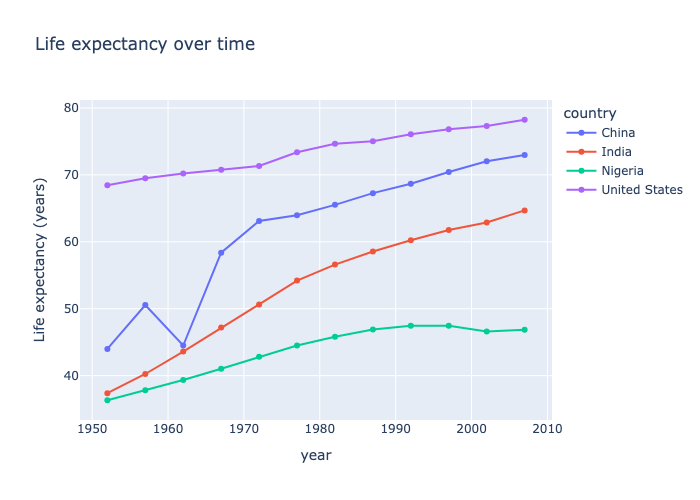

In [9]:
countries = ["China", "India", "United States", "Nigeria"]
fig = px.line(gapminder[gapminder["country"].isin(countries)], x="year", y="lifeExp", color="country",
              markers=True, title="Life expectancy over time", labels={"lifeExp": "Life expectancy (years)"})
fig.show()

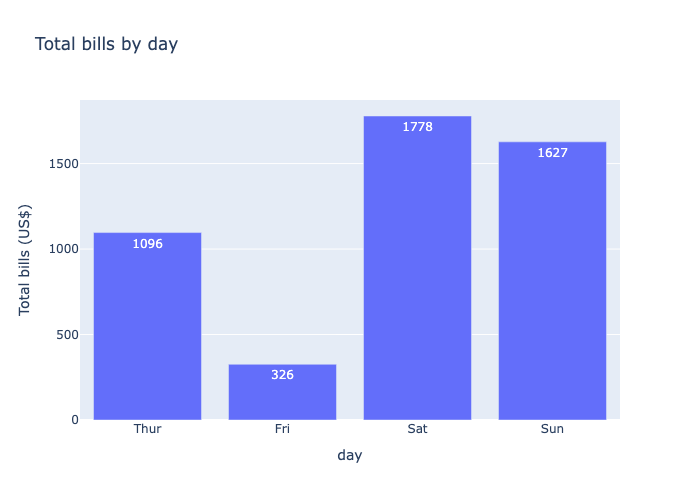

In [10]:
revenue = tips.groupby("day", as_index=False)["total_bill"].sum()     # aggregate FIRST: one row per bar
fig = px.bar(revenue, x="day", y="total_bill", text_auto=".0f", category_orders={"day": DAY_ORDER},
             title="Total bills by day", labels={"total_bill": "Total bills (US$)"})
fig.show()

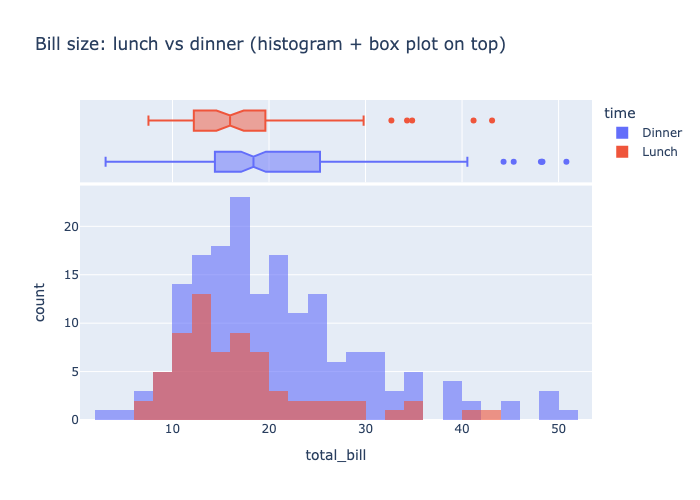

{'Dinner': 18.39, 'Lunch': 15.96}


In [11]:
fig = px.histogram(tips, x="total_bill", color="time", nbins=30, barmode="overlay", opacity=0.6,
                   marginal="box", title="Bill size: lunch vs dinner (histogram + box plot on top)")
fig.show()
print(tips.groupby("time")["total_bill"].median().round(2).to_dict())

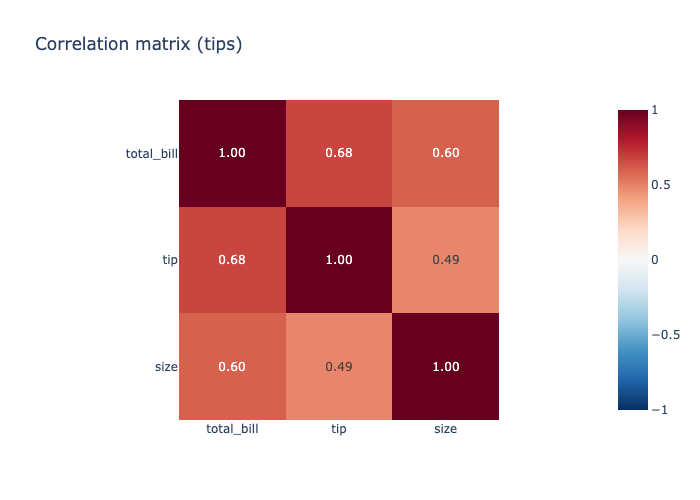

In [12]:
corr = tips[["total_bill", "tip", "size"]].corr()
fig = px.imshow(corr, text_auto=".2f", color_continuous_scale="RdBu_r", zmin=-1, zmax=1,
                title="Correlation matrix (tips)")
fig.show()

### ✍️ Your Turn

Make `fig_box`: a **box plot of `tip` by `day`** with the days in the natural order `DAY_ORDER` (not the order they happen to appear in the file).

In [13]:
fig_box = None  # TODO: px.box(...)
check("box_order",
      None if fig_box is None else list(fig_box.layout.xaxis.categoryarray or []),
      DAY_ORDER, hint="Pass category_orders={'day': DAY_ORDER}.")

⏳ box_order: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
fig_box = px.box(tips, x="day", y="tip", category_orders={"day": DAY_ORDER}, points="outliers")
check("box_order", list(fig_box.layout.xaxis.categoryarray or []), DAY_ORDER)
```
</details>

> 💡 **Interview angle:** "How would you show a model's error distribution?" — a histogram (or box plot per segment) of residuals, not just a single RMSE number; segments with wide boxes are where the model is unreliable.

## 4. Hover Labels, Colors, and Facets 🟡

- **`hover_data`** adds columns to the hover box — and formats them (`":,"` thousands separator, `":$,.0f"` dollars, `False` to hide).
- **`hovertemplate`** (Graph Objects) gives complete control; `<extra></extra>` removes the grey trace-name box.
- **`color_discrete_map`** pins a color to each category so it stays the same across charts.
- **Facets** (`facet_col`, `facet_row`) split one chart into a grid of small charts — one per category ("small multiples").

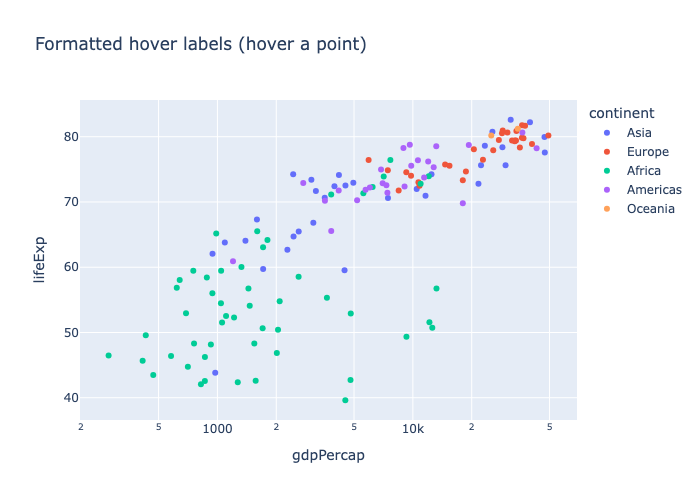

hovertemplate px generated:
 <b>%{hovertext}</b><br><br>gdpPercap=%{x:$,.0f}<br>lifeExp=%{y:.1f}<br>pop=%{customdata[0]:,}<extra></extra>


In [14]:
fig = px.scatter(
    gap2007, x="gdpPercap", y="lifeExp", color="continent", hover_name="country", log_x=True,
    hover_data={"pop": ":,", "gdpPercap": ":$,.0f", "lifeExp": ":.1f", "continent": False},
    title="Formatted hover labels (hover a point)",
)
fig.show()
print("hovertemplate px generated:\n", fig.data[0].hovertemplate)

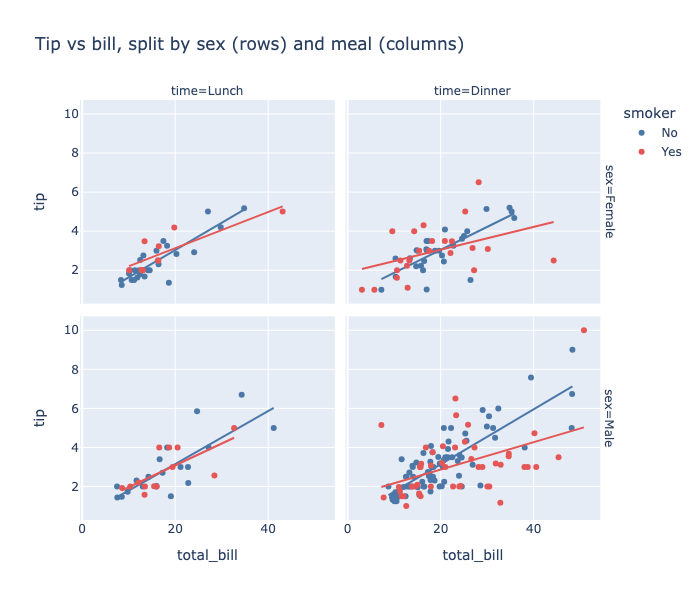

smoker    sex   time  tip per extra $1 of bill
    No Female  Lunch                     0.140
    No   Male  Lunch                     0.136
   Yes Female  Lunch                     0.093
   Yes   Male  Lunch                     0.112
    No Female Dinner                     0.118
    No   Male Dinner                     0.141
   Yes Female Dinner                     0.058
   Yes   Male Dinner                     0.070


In [15]:
SMOKER_COLORS = {"Yes": "#E45756", "No": "#4C78A8"}
fig = px.scatter(
    tips, x="total_bill", y="tip", color="smoker", color_discrete_map=SMOKER_COLORS,
    facet_col="time", facet_row="sex", trendline="ols",       # ols = ordinary least squares line (uses statsmodels)
    category_orders={"time": ["Lunch", "Dinner"]}, height=600,
    title="Tip vs bill, split by sex (rows) and meal (columns)",
)
fig.show()

# The fitted slopes are real regression results — read them instead of eyeballing the lines
trend = px.get_trendline_results(fig)
trend["tip per extra $1 of bill"] = trend["px_fit_results"].map(lambda res: round(float(res.params[1]), 3))
print(trend.drop(columns="px_fit_results").to_string(index=False))

### ✍️ Your Turn

Make `fig_facets`: the 2007 GDP-vs-life-expectancy scatter (log x-axis) **split into one small chart per continent**, wrapping after 3 charts per row.

In [16]:
fig_facets = None  # TODO: px.scatter(gap2007, ..., facet_col=..., facet_col_wrap=...)
check("facets",
      None if fig_facets is None else [len(fig_facets.data), len(fig_facets.layout.annotations)],
      [5, 5], hint="facet_col='continent', facet_col_wrap=3 → 5 traces and 5 facet title annotations.")

⏳ facets: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
fig_facets = px.scatter(gap2007, x="gdpPercap", y="lifeExp", facet_col="continent", facet_col_wrap=3,
                        log_x=True, hover_name="country")
check("facets", [len(fig_facets.data), len(fig_facets.layout.annotations)], [5, 5])
```
Each facet gets its own trace, and its title ("continent=Asia") is a layout annotation.
</details>

> 💡 **Interview angle:** "Your model looks fine overall — how do you check it is fine for every segment?" — facet the error or calibration plot by segment (region, device, customer tier). Aggregate metrics hide subgroups where the model fails.

## 5. Animation Frames 🟡

Pass `animation_frame="year"` and Plotly creates one **frame** per year plus a play button and slider. `animation_group="country"` tells plotly.js which point in one frame *is the same object* in the next, so bubbles glide instead of jumping.

⚠️ Always fix the axis ranges (`range_x`, `range_y`) — otherwise the axes are sized for the first frame only (see Pitfall 3).

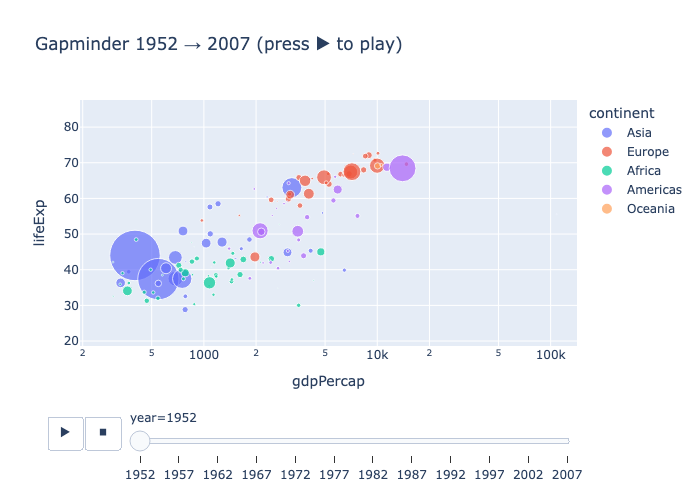

frames: 12 | first: 1952 | last: 2007
median life expectancy: 45.1 years in 1952 → 71.9 in 2007


In [17]:
fig = px.scatter(
    gapminder, x="gdpPercap", y="lifeExp", size="pop", color="continent", hover_name="country",
    animation_frame="year", animation_group="country", log_x=True, size_max=55,
    range_x=[gapminder["gdpPercap"].min() * 0.8, gapminder["gdpPercap"].max() * 1.25],
    range_y=[gapminder["lifeExp"].min() - 5, gapminder["lifeExp"].max() + 5],
    title="Gapminder 1952 → 2007 (press ▶ to play)",
)
fig.show()

print("frames:", len(fig.frames), "| first:", fig.frames[0].name, "| last:", fig.frames[-1].name)
median_life = gapminder.groupby("year")["lifeExp"].median()
print(f"median life expectancy: {median_life.iloc[0]:.1f} years in 1952 → {median_life.iloc[-1]:.1f} in 2007")

The static PNG snapshot (what GitHub shows) can only show the **first frame**. For a report, small multiples (`facet_col="year"`) often communicate change better than an animation, because the reader can compare years side by side.

> 💡 **Interview angle:** "Animation or small multiples?" — animation is great for *engagement* and showing motion; small multiples are better for *comparison* because they don't rely on the viewer's memory of earlier frames.

## 6. Subplots with `make_subplots` 🟡

`px` facets only split *one* chart type by a category. To combine **different** charts in one figure, create a grid with `make_subplots` and add Graph Objects traces with `row=` and `col=`.

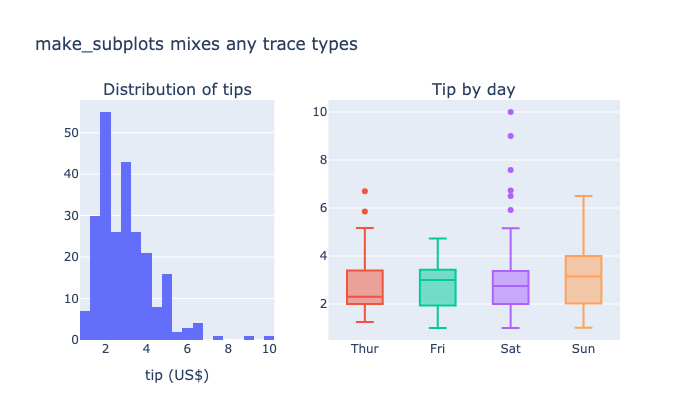

trace → axes: [('histogram', 'all tips', 'x', 'y'), ('box', 'Thur', 'x2', 'y2'), ('box', 'Fri', 'x2', 'y2'), ('box', 'Sat', 'x2', 'y2'), ('box', 'Sun', 'x2', 'y2')]


In [18]:
fig = make_subplots(rows=1, cols=2, column_widths=[0.4, 0.6], subplot_titles=("Distribution of tips", "Tip by day"))
fig.add_trace(go.Histogram(x=tips["tip"], nbinsx=25, name="all tips"), row=1, col=1)
for day in DAY_ORDER:
    fig.add_trace(go.Box(y=tips.loc[tips["day"] == day, "tip"], name=day), row=1, col=2)
fig.update_layout(title="make_subplots mixes any trace types", showlegend=False, height=420)
fig.update_xaxes(title_text="tip (US$)", row=1, col=1)
fig.show()
print("trace → axes:", [(t.type, t.name, t.xaxis, t.yaxis) for t in fig.data])

**Two y-axes** on one chart (`secondary_y`) are useful when two series share an x-axis but have different units. Use sparingly — readers can misread which line belongs to which axis.

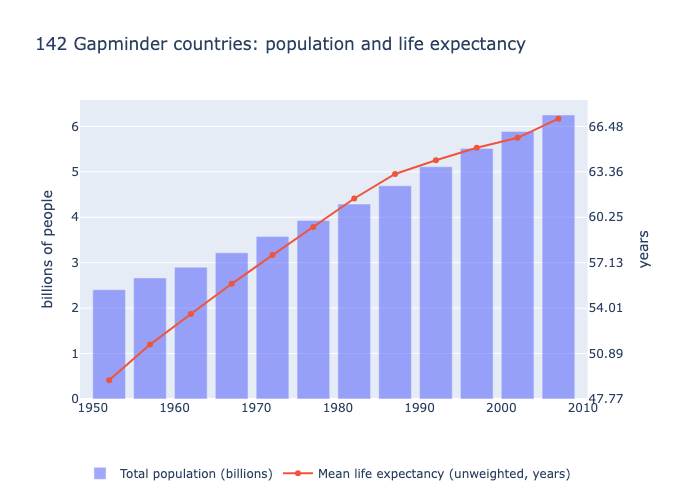

In [19]:
world = gapminder.groupby("year").agg(pop=("pop", "sum"), life=("lifeExp", "mean")).reset_index()

fig = make_subplots(specs=[[{"secondary_y": True}]])
fig.add_trace(go.Bar(x=world["year"], y=world["pop"] / 1e9, name="Total population (billions)", opacity=0.6), secondary_y=False)
fig.add_trace(go.Scatter(x=world["year"], y=world["life"], name="Mean life expectancy (unweighted, years)",
                         mode="lines+markers"), secondary_y=True)
fig.update_yaxes(title_text="billions of people", secondary_y=False)
fig.update_yaxes(title_text="years", secondary_y=True)
fig.update_layout(title="142 Gapminder countries: population and life expectancy", legend=dict(orientation="h", y=-0.2))
fig.show()

### ✍️ Your Turn

Make `fig_china`: **two rows sharing one x-axis** (`year`). Row 1: China's population as a line. Row 2: China's life expectancy as a line.

In [20]:
china = gapminder[gapminder["country"] == "China"]
fig_china = None  # TODO: make_subplots(rows=2, cols=1, shared_xaxes=True) + two add_trace calls
check("china_subplots",
      None if fig_china is None else [len(fig_china.data), [t.yaxis for t in fig_china.data]],
      [2, ["y", "y2"]], hint="add_trace(go.Scatter(...), row=1, col=1) and then row=2, col=1.")

⏳ china_subplots: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
china = gapminder[gapminder["country"] == "China"]
fig_china = make_subplots(rows=2, cols=1, shared_xaxes=True, subplot_titles=("Population", "Life expectancy"))
fig_china.add_trace(go.Scatter(x=china["year"], y=china["pop"], mode="lines", name="population"), row=1, col=1)
fig_china.add_trace(go.Scatter(x=china["year"], y=china["lifeExp"], mode="lines", name="life expectancy"), row=2, col=1)
check("china_subplots", [len(fig_china.data), [t.yaxis for t in fig_china.data]], [2, ["y", "y2"]])
```
</details>

## 7. Layout, Templates, and Styling 🟢

Four methods cover almost all styling:

| Method | Changes | Example |
|---|---|---|
| `fig.update_layout(...)` | the whole figure | `title`, `font`, `legend`, `margin`, `template`, `height` |
| `fig.update_traces(...)` | every trace (or a `selector`) | `marker_color`, `texttemplate`, `line_width` |
| `fig.update_xaxes(...)` / `update_yaxes(...)` | axes | `tickprefix="$"`, `range`, `showgrid` |
| `fig.add_hline / add_vline / add_annotation` | reference lines and notes | a target, an average, an event |

A **template** is a saved bundle of styling. Pass `template="plotly_white"` per figure, or set `pio.templates.default` once.

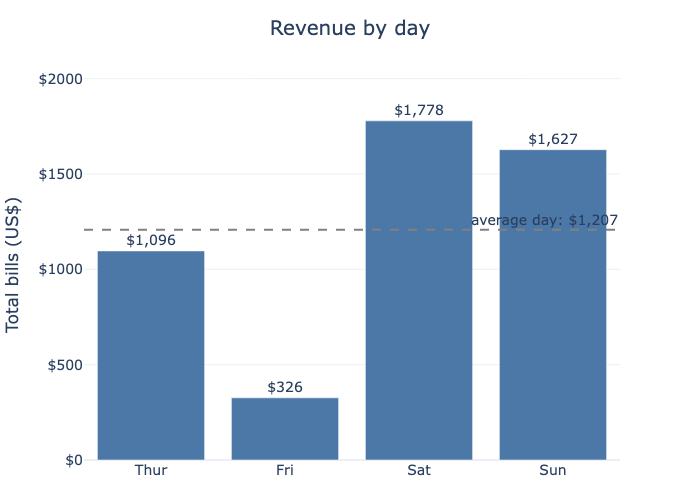

built-in templates: ['ggplot2', 'seaborn', 'simple_white', 'plotly', 'plotly_white', 'plotly_dark', 'presentation', 'xgridoff', 'ygridoff', 'gridon', 'none']


In [21]:
average_day = revenue["total_bill"].mean()

fig = px.bar(revenue, x="day", y="total_bill", category_orders={"day": DAY_ORDER}, template="plotly_white")
fig.update_traces(marker_color="#4C78A8", texttemplate="$%{y:,.0f}", textposition="outside")
fig.update_layout(title=dict(text="Revenue by day", x=0.5), font=dict(size=14), yaxis_title="Total bills (US$)",
                  xaxis_title=None, margin=dict(t=70, b=40))
fig.update_yaxes(tickprefix="$", range=[0, revenue["total_bill"].max() * 1.15])
fig.add_hline(y=average_day, line_dash="dash", line_color="grey", annotation_text=f"average day: ${average_day:,.0f}")
fig.show()

print("built-in templates:", list(pio.templates))

> 💡 **Interview angle:** "How do you make charts consistent across a team's reports?" — define one custom template (fonts, colors, logo) registered in `pio.templates`, and a fixed `color_discrete_map` for recurring categories (e.g. model names), so "model A" is the same color everywhere.

## 8. Maps 🟡

Gapminder includes 3-letter **ISO country codes** (`iso_alpha`), which is all `px.choropleth` needs to color countries. (Country outlines are loaded by plotly.js from a CDN, so drawing a map needs an internet connection.)

| Map type | Function | Needs |
|---|---|---|
| Filled regions | `px.choropleth` | ISO codes, US state codes, or your own GeoJSON |
| Points on a globe | `px.scatter_geo` | latitude/longitude or ISO codes |
| Points on street tiles | `px.scatter_map` (MapLibre; the old `*_mapbox` functions are deprecated) | latitude/longitude + internet for tiles |

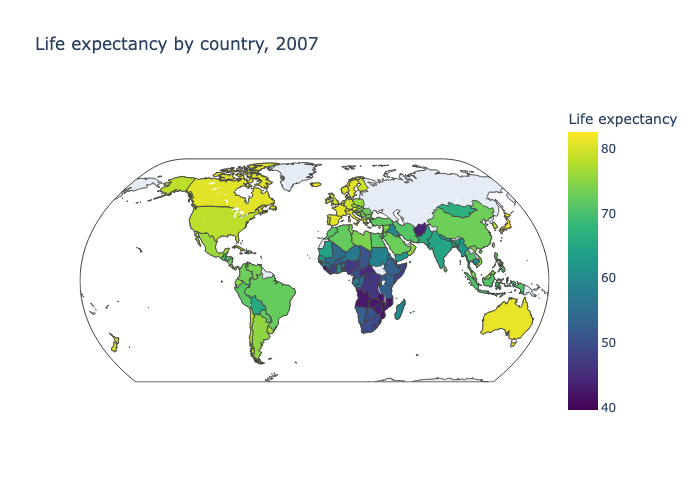

lowest: Swaziland (39.6) | highest: Japan (82.6)


In [22]:
fig = px.choropleth(gap2007, locations="iso_alpha", color="lifeExp", hover_name="country",
                    color_continuous_scale="Viridis", projection="natural earth",
                    labels={"lifeExp": "Life expectancy"}, title="Life expectancy by country, 2007")
try:
    fig.show()
except Exception as err:                        # noqa: BLE001 — honest message instead of a broken cell
    print(f"⏭️ Skipped drawing the map ({type(err).__name__}): country outlines need an internet connection.")

lowest, highest = gap2007.nsmallest(1, "lifeExp").iloc[0], gap2007.nlargest(1, "lifeExp").iloc[0]
print(f"lowest: {lowest['country']} ({lowest['lifeExp']:.1f}) | highest: {highest['country']} ({highest['lifeExp']:.1f})")

> 💡 **Interview angle:** "Choropleth pitfalls?" — big countries dominate visually even when they have few data points, and colouring *totals* mostly shows population. Map **rates** (per capita, per 1,000), not raw counts.

## 9. Renderers and Exporting: HTML and Static Images 🟢

A **renderer** decides what `fig.show()` produces. Renderers can be combined with `+`.

| Renderer | Output | Good for |
|---|---|---|
| `plotly_mimetype` | interactive chart (JSON the frontend draws) | JupyterLab, Notebook 7, VS Code |
| `notebook_connected` | HTML + plotly.js from a CDN | classic notebooks, nbviewer |
| `png` / `svg` | static image made by kaleido | **GitHub**, PDFs, emails |
| `browser` | opens a new browser tab | plain `.py` scripts |
| `colab` | Colab's own format | Google Colab |

To **save** a figure:

| Call | File | Notes |
|---|---|---|
| `fig.write_html(path, include_plotlyjs="cdn")` | interactive web page | tiny file, needs internet to load plotly.js |
| `fig.write_html(path, include_plotlyjs=True)` | interactive, fully offline | embeds all of plotly.js (~4–5 MB) |
| `fig.to_html(full_html=False)` | an HTML `<div>` snippet | put several charts on one page |
| `fig.write_image(path, width=, height=, scale=)` | PNG / SVG / PDF / JPEG | needs kaleido + Chrome |

In [23]:
print("current renderer:", pio.renderers.default)

fig = px.scatter(gap2007, x="gdpPercap", y="lifeExp", color="continent", hover_name="country", log_x=True,
                 title="Export demo")
html_cdn, html_offline = OUTPUT_DIR / "export_cdn.html", OUTPUT_DIR / "export_offline.html"
fig.write_html(html_cdn, include_plotlyjs="cdn")
fig.write_html(html_offline, include_plotlyjs=True)
print(f"HTML with plotly.js from CDN : {html_cdn.stat().st_size / 1024:8.1f} KB")
print(f"HTML with plotly.js embedded : {html_offline.stat().st_size / 1024:8.1f} KB")

current renderer: plotly_mimetype+png
HTML with plotly.js from CDN :     14.5 KB
HTML with plotly.js embedded :   4207.1 KB


In [24]:
if STATIC_OK:
    for fmt, scale in [("png", 2), ("svg", 1), ("pdf", 1)]:
        path = OUTPUT_DIR / f"export.{fmt}"
        fig.write_image(path, width=900, height=500, scale=scale)   # scale=2 → 1800×1000 px, crisp on retina/slides
        print(f"{fmt.upper():4s} → {path} ({path.stat().st_size / 1024:.0f} KB)")
else:
    print("⏭️ Skipped static export: kaleido could not find Chrome (run `plotly_get_chrome`, then restart the kernel).")

PNG  → _outputs/export.png (126 KB)


SVG  → _outputs/export.svg (43 KB)


PDF  → _outputs/export.pdf (38 KB)


> 💡 **Interview angle:** "My Plotly charts show in Jupyter but are blank on GitHub (or in a script). Why?" — the chart is JavaScript. GitHub doesn't run it, and a script has no notebook frontend. Save a static image (`png` renderer or `write_image`), or `write_html` and open the file.

## 10. Buttons and Sliders 🔴

Plotly figures can carry their own **controls** — no server, no Python running — because every button stores the change it applies.

| `method` | What the control changes | Typical use |
|---|---|---|
| `"restyle"` | trace properties (`visible`, `y`, `marker.color`) | switch the metric shown |
| `"relayout"` | layout properties (`yaxis.type`, `shapes`, `title.text`) | log/linear toggle, move a marker line |
| `"update"` | both at once: `args=[trace_changes, layout_changes]` | switch metric **and** title |
| `"animate"` | jump to animation frames | custom play buttons |

**Dropdown (`updatemenus`)**: draw all traces, show one, and let each button choose which are `visible`.

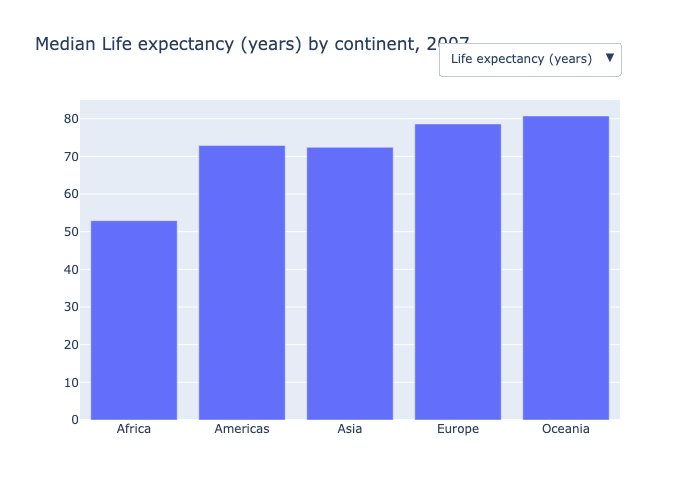

In [25]:
METRICS = {"lifeExp": "Life expectancy (years)", "gdpPercap": "GDP per capita (US$)", "pop": "Population"}
by_continent = gap2007.groupby("continent")[list(METRICS)].median()

fig = go.Figure()
for i, (column, label) in enumerate(METRICS.items()):
    fig.add_trace(go.Bar(x=by_continent.index, y=by_continent[column], name=label, visible=(i == 0)))

buttons = [
    dict(label=label, method="update",
         args=[{"visible": [j == i for j in range(len(METRICS))]},          # trace changes
               {"title.text": f"Median {label} by continent, 2007"}])        # layout changes
    for i, label in enumerate(METRICS.values())
]
fig.update_layout(updatemenus=[dict(buttons=buttons, direction="down", x=1.0, xanchor="right", y=1.18)],
                  title=f"Median {list(METRICS.values())[0]} by continent, 2007")
fig.show()

**Slider (`sliders`)**: a slider is a list of `steps`; each step has a `label` and the same `method`/`args` as a button. Here each step makes one year's histogram visible.

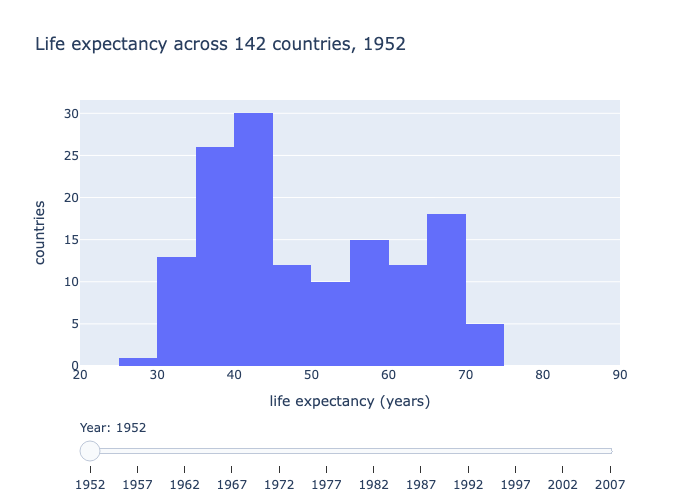

slider steps: 12


In [26]:
years = sorted(gapminder["year"].unique().tolist())
fig = go.Figure()
for year in years:
    fig.add_trace(go.Histogram(x=gapminder.loc[gapminder["year"] == year, "lifeExp"],
                               xbins=dict(start=20, end=90, size=5), name=str(year), visible=(year == years[0])))

steps = [dict(label=str(year), method="update",
              args=[{"visible": [y == year for y in years]}, {"title.text": f"Life expectancy across 142 countries, {year}"}])
         for year in years]
fig.update_layout(sliders=[dict(active=0, steps=steps, currentvalue={"prefix": "Year: "}, pad={"t": 50})],
                  title=f"Life expectancy across 142 countries, {years[0]}",
                  xaxis_title="life expectancy (years)", yaxis_title="countries", xaxis_range=[20, 90])
fig.show()
print("slider steps:", len(fig.layout.sliders[0].steps))

### ✍️ Your Turn

Add a dropdown to `fig_pop` with **two buttons, "Linear" then "Log"**, that switch the y-axis type with `method="relayout"` and `args=[{"yaxis.type": "linear"}]` / `args=[{"yaxis.type": "log"}]`.

In [27]:
pop_by_continent = gap2007.groupby("continent", as_index=False)["pop"].sum()
fig_pop = px.bar(pop_by_continent, x="continent", y="pop", title="Population by continent, 2007")
# TODO: fig_pop.update_layout(updatemenus=[dict(buttons=[...])])
menus = fig_pop.layout.updatemenus
check("log_toggle",
      None if not menus else [[b.label for b in menus[0].buttons], [b.args[0]["yaxis.type"] for b in menus[0].buttons]],
      [["Linear", "Log"], ["linear", "log"]], hint="Each button: dict(label=..., method='relayout', args=[{'yaxis.type': ...}])")

⏳ log_toggle: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
pop_by_continent = gap2007.groupby("continent", as_index=False)["pop"].sum()
fig_pop = px.bar(pop_by_continent, x="continent", y="pop", title="Population by continent, 2007")
fig_pop.update_layout(updatemenus=[dict(buttons=[
    dict(label="Linear", method="relayout", args=[{"yaxis.type": "linear"}]),
    dict(label="Log", method="relayout", args=[{"yaxis.type": "log"}]),
])])
menus = fig_pop.layout.updatemenus
check("log_toggle", [[b.label for b in menus[0].buttons], [b.args[0]["yaxis.type"] for b in menus[0].buttons]],
      [["Linear", "Log"], ["linear", "log"]])
```
</details>

> 💡 **Interview angle:** "Why would a slider-in-HTML dashboard beat a Streamlit app?" — it's a single static file: no server to host, no Python at view time, trivial to email or attach to a ticket. The trade-off: every state must be **precomputed** (fine for 100 thresholds, not for live queries over a database).

## 🔧 Build It From Scratch

### 1) A chart without Plotly Express

A Plotly Express call is "just" a function that groups a DataFrame and writes a JSON spec. Let's write that function ourselves as **plain dictionaries**, then prove it matches `px`.

✅ our dict-built figure has the same traces, points, and axis type as px.scatter
validation error: Invalid property specified for object of type plotly.graph_objs.Layout: 'xaxiss' → Did you mean "xaxis"?


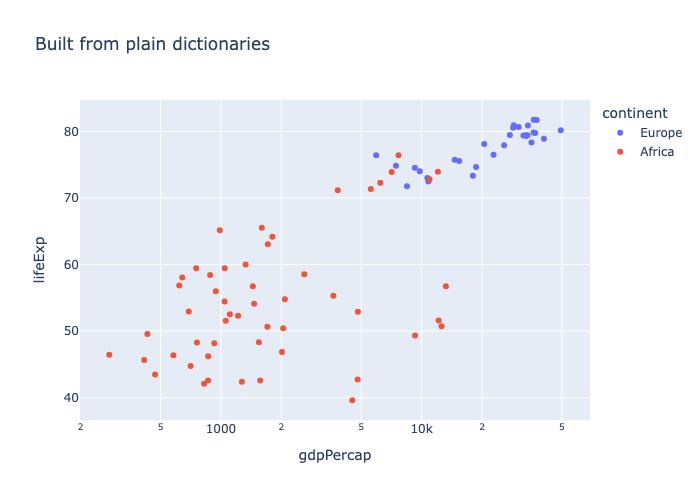

In [28]:
subset = gap2007[gap2007["continent"].isin(["Europe", "Africa"])]
fig_px = px.scatter(subset, x="gdpPercap", y="lifeExp", color="continent", log_x=True)


def scatter_from_scratch(df, x, y, color, log_x=False):
    """Return a Plotly figure spec as plain dicts: one marker trace per category, in order of first appearance."""
    traces = []
    for name in df[color].unique():
        part = df[df[color] == name]
        traces.append({"type": "scatter", "mode": "markers", "name": name,
                       "x": part[x].to_numpy(), "y": part[y].to_numpy()})
    layout = {
        "xaxis": {"title": {"text": x}, "type": "log" if log_x else "linear"},
        "yaxis": {"title": {"text": y}},
        "legend": {"title": {"text": color}},
    }
    return {"data": traces, "layout": layout}


spec = scatter_from_scratch(subset, "gdpPercap", "lifeExp", "continent", log_x=True)
fig_scratch = go.Figure(spec)                  # go.Figure validates every key in the dict

assert len(fig_scratch.data) == len(fig_px.data)
for ours, theirs in zip(fig_scratch.data, fig_px.data):
    assert (ours.type, ours.mode, ours.name) == (theirs.type, theirs.mode, theirs.name)
    assert np.allclose(ours.x, theirs.x) and np.allclose(ours.y, theirs.y)
assert fig_scratch.layout.xaxis.type == fig_px.layout.xaxis.type == "log"
print("✅ our dict-built figure has the same traces, points, and axis type as px.scatter")

try:
    go.Figure({"data": [], "layout": {"xaxiss": {}}})  # typo → Plotly tells you exactly what's wrong
except ValueError as err:
    lines = str(err).splitlines()
    print("validation error:", lines[0], "→", lines[2])

fig_scratch.update_layout(title="Built from plain dictionaries")
fig_scratch.show()

### 2) An interactive HTML page by hand

`write_html` = figure JSON + a `<script>` tag that loads plotly.js + one call to `Plotly.newPlot`. Here it is in a few lines.

In [29]:
PLOTLYJS_VERSION = plotly.offline.get_plotlyjs_version()


def html_from_scratch(fig, div_id="chart"):
    payload = fig.to_json()
    return f"""<!doctype html>
<html><head><meta charset="utf-8">
<script src="https://cdn.plot.ly/plotly-{PLOTLYJS_VERSION}.min.js"></script></head>
<body><div id="{div_id}" style="height:500px"></div>
<script>const fig = {payload}; Plotly.newPlot("{div_id}", fig.data, fig.layout);</script>
</body></html>"""


page = html_from_scratch(fig_scratch)
(OUTPUT_DIR / "scratch_chart.html").write_text(page)

embedded = re.search(r"const fig = (\{.*\}); Plotly\.newPlot", page, re.S).group(1)
assert json.loads(go.Figure(json.loads(embedded)).to_json()) == json.loads(fig_scratch.to_json())
assert f"cdn.plot.ly/plotly-{PLOTLYJS_VERSION}.min.js" in fig_scratch.to_html(include_plotlyjs="cdn")
print(f"✅ page written ({len(page) / 1024:.1f} KB); embedded JSON round-trips to the same figure;"
      f" it loads the same plotly.js {PLOTLYJS_VERSION} as write_html")

✅ page written (8.8 KB); embedded JSON round-trips to the same figure; it loads the same plotly.js 4.0.0 as write_html


### 3) Precision and recall at every threshold, vectorized

The dashboard in the mini project needs precision and recall at many thresholds. Instead of looping, compare **all thresholds with all scores at once** using broadcasting: a `(n_thresholds, n_samples)` boolean matrix of predictions.

We use a real score: the **"worst concave points"** measurement from the breast-cancer dataset (bigger → more likely malignant). Remember: in this dataset **target 0 = malignant**, so we flip it to make malignant the positive class.

In [30]:
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import precision_recall_curve

cancer = load_breast_cancer(as_frame=True)
is_malignant = (cancer.target == 0).to_numpy().astype(int)      # target 0 = malignant → positive class 1
concave_score = cancer.data["worst concave points"].to_numpy()


def pr_at_thresholds(y_true, scores, thresholds):
    """Precision and recall when predicting positive for score >= threshold, for every threshold at once."""
    y_true = np.asarray(y_true).astype(bool)
    pred = np.asarray(scores)[None, :] >= np.asarray(thresholds)[:, None]    # (n_thresholds, n_samples)
    tp = (pred & y_true).sum(axis=1)
    fp = (pred & ~y_true).sum(axis=1)
    fn = (~pred & y_true).sum(axis=1)
    precision = np.divide(tp, tp + fp, out=np.ones(len(tp)), where=(tp + fp) > 0)   # no positives predicted → 1 (sklearn's convention)
    recall = tp / (tp + fn)
    return precision, recall


sk_precision, sk_recall, sk_thresholds = precision_recall_curve(is_malignant, concave_score)
our_precision, our_recall = pr_at_thresholds(is_malignant, concave_score, sk_thresholds)
assert np.allclose(our_precision, sk_precision[:-1]) and np.allclose(our_recall, sk_recall[:-1])
print(f"✅ matches sklearn.metrics.precision_recall_curve at all {len(sk_thresholds)} thresholds")

✅ matches sklearn.metrics.precision_recall_curve at all 492 thresholds


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — `px.bar` on raw rows draws one sliver per row

`px.bar` does **not** aggregate. Given 244 raw bills, it stacks 244 thin segments; the total height looks right, but hover shows single bills and the chart is slow and striped.

❌ raw rows   → 244 bar segments for 4 days


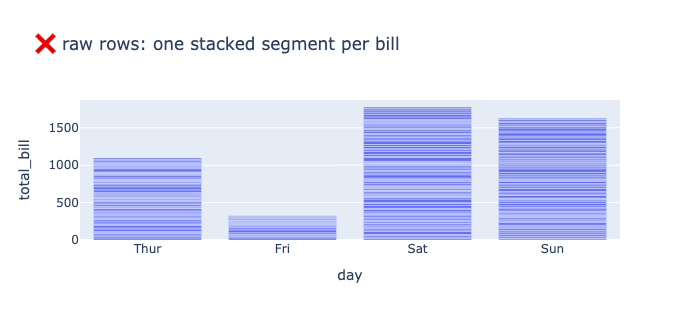

✅ aggregated → 4 bars; totals match the data: True


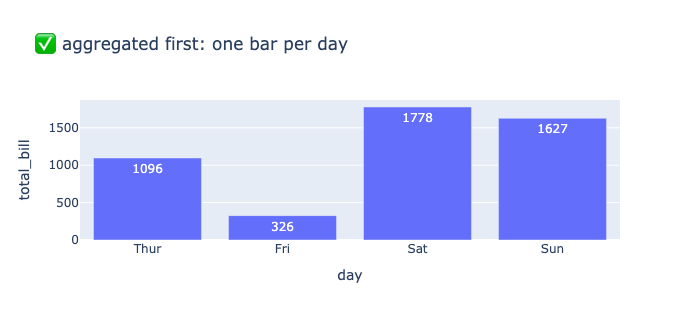

In [31]:
fig_wrong = px.bar(tips, x="day", y="total_bill", category_orders={"day": DAY_ORDER},
                   title="❌ raw rows: one stacked segment per bill", height=320)
print(f"❌ raw rows   → {len(fig_wrong.data[0].x)} bar segments for 4 days")
fig_wrong.show()

daily = tips.groupby("day", as_index=False)["total_bill"].sum()
fig_right = px.bar(daily, x="day", y="total_bill", category_orders={"day": DAY_ORDER}, text_auto=".0f",
                   title="✅ aggregated first: one bar per day", height=320)
print(f"✅ aggregated → {len(fig_right.data[0].x)} bars; totals match the data: {np.isclose(daily['total_bill'].sum(), tips['total_bill'].sum())}")
fig_right.show()

### ❌ Pitfall 2 — Categories in "file order"

Without `category_orders`, categories appear in the order they are first seen in the data — here Sunday comes first.

In [32]:
wrong_order = list(dict.fromkeys(px.box(tips, x="day", y="tip").data[0].x))
right_order = list(px.box(tips, x="day", y="tip", category_orders={"day": DAY_ORDER}).layout.xaxis.categoryarray)
print("❌ default order:", wrong_order)
print("✅ with category_orders:", right_order)

❌ default order: ['Sun', 'Sat', 'Thur', 'Fri']
✅ with category_orders: ['Thur', 'Fri', 'Sat', 'Sun']


### ❌ Pitfall 3 — Animations without fixed axis ranges

The axis range is computed from the **first frame**. Points that grow beyond it in later frames fly off the chart. We can ask Plotly for the ranges it actually computes with `pio.full_figure_for_development` (it uses kaleido).

In [33]:
if STATIC_OK:
    no_range = px.scatter(gapminder, x="gdpPercap", y="lifeExp", animation_frame="year", log_x=True)
    auto_y = pio.full_figure_for_development(no_range, warn=False).layout.yaxis.range
    off_auto = int((gap2007["lifeExp"] > auto_y[1]).sum())
    print(f"❌ auto y-range (sized for the 1952 frame): {auto_y[0]:.1f}–{auto_y[1]:.1f} years → "
          f"{off_auto} of {len(gap2007)} countries sit above it in 2007 and vanish off the top")

    fixed = px.scatter(gapminder, x="gdpPercap", y="lifeExp", animation_frame="year", log_x=True,
                       range_y=[gapminder["lifeExp"].min() - 5, gapminder["lifeExp"].max() + 5])
    fixed_y = fixed.layout.yaxis.range
    off_fixed = int(((gapminder["lifeExp"] > fixed_y[1]) | (gapminder["lifeExp"] < fixed_y[0])).sum())
    print(f"✅ range_y fixed to {fixed_y[0]:.1f}–{fixed_y[1]:.1f} years for every frame → {off_fixed} points off-screen in any year")
else:
    print("⏭️ Skipped: full_figure_for_development needs kaleido + Chrome.")

❌ auto y-range (sized for the 1952 frame): 25.6–75.8 years → 38 of 142 countries sit above it in 2007 and vanish off the top
✅ range_y fixed to 18.6–87.6 years for every frame → 0 points off-screen in any year


### ❌ Pitfall 4 — A waterfall whose "total" bar double-counts

In `go.Waterfall`, each bar has a `measure`: `"absolute"` (start value), `"relative"` (a change), or `"total"` (the running sum). If you pass the final total as `"relative"`, Plotly **adds it again**. Always compute the bridge in pandas and assert it closes *before* plotting.

Real example: how did the total population of the 142 Gapminder countries grow from 1952 to 2007, by continent?

❌ final bar as 'relative': 12.50 B  (true 2007 total is 6.25 B)
✅ final bar as 'total'   : 6.25 B


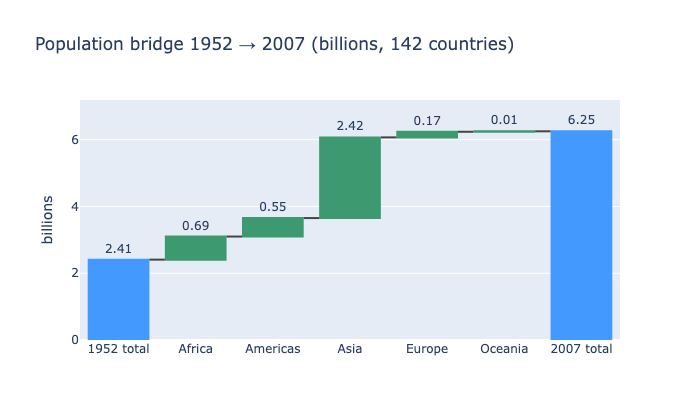

In [34]:
pop_by_year = gapminder[gapminder["year"].isin([1952, 2007])].pivot_table(index="continent", columns="year", values="pop", aggfunc="sum")
start_total, end_total = pop_by_year[1952].sum() / 1e9, pop_by_year[2007].sum() / 1e9
changes = (pop_by_year[2007] - pop_by_year[1952]) / 1e9

labels = ["1952 total", *changes.index, "2007 total"]
values = [start_total, *changes.values, end_total]

# What the chart's last bar shows under each measure choice (mirrors plotly.js's running sum)
wrong_last_bar = start_total + changes.sum() + end_total          # ❌ "relative" → adds the total again
right_last_bar = start_total + changes.sum()                      # ✅ "total" → shows the running sum
print(f"❌ final bar as 'relative': {wrong_last_bar:.2f} B  (true 2007 total is {end_total:.2f} B)")
print(f"✅ final bar as 'total'   : {right_last_bar:.2f} B")
assert np.isclose(right_last_bar, end_total), "the bridge does not close — check the changes"

fig = go.Figure(go.Waterfall(
    x=labels, y=values, measure=["absolute", *["relative"] * len(changes), "total"],
    texttemplate="%{y:.2f}", textposition="outside",
))
fig.update_layout(title="Population bridge 1952 → 2007 (billions, 142 countries)", yaxis_title="billions", height=420,
                  yaxis_range=[0, end_total * 1.15])
fig.show()

### ❌ Pitfall 5 — Embedding plotly.js in every HTML file

`include_plotlyjs=True` (the default for `write_html`) copies all of plotly.js into **each** file. Fifty model reports = hundreds of MB in your repo or email.

In [35]:
sizes = {"❌ include_plotlyjs=True ": html_offline.stat().st_size, "✅ include_plotlyjs='cdn'": html_cdn.stat().st_size}
for label, size in sizes.items():
    print(f"{label}: {size / 1024:8.1f} KB per file → 50 reports ≈ {50 * size / 1e6:6.1f} MB")

❌ include_plotlyjs=True :   4207.1 KB per file → 50 reports ≈  215.4 MB
✅ include_plotlyjs='cdn':     14.5 KB per file → 50 reports ≈    0.7 MB


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Overlaid histograms
Make `fig_ex1`: a histogram of `total_bill` from `tips` with **20 bins**, **colored by `time`** (Lunch vs Dinner).

In [36]:
fig_ex1 = None  # TODO
check("ex1_histogram", None if fig_ex1 is None else [len(fig_ex1.data), fig_ex1.data[0].nbinsx], [2, 20],
      hint="px.histogram(tips, x='total_bill', color='time', nbins=20)")

⏳ ex1_histogram: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
fig_ex1 = px.histogram(tips, x="total_bill", color="time", nbins=20, barmode="overlay", opacity=0.6)
check("ex1_histogram", [len(fig_ex1.data), fig_ex1.data[0].nbinsx], [2, 20])
```
</details>

### 🟢 Exercise 2 — Line chart with markers
Make `fig_ex2`: life expectancy over time for **Japan, Brazil, and Nigeria**, one colored line per country, **with markers**.

In [37]:
fig_ex2 = None  # TODO
check("ex2_lines",
      None if fig_ex2 is None else [sorted(t.name for t in fig_ex2.data), fig_ex2.data[0].mode],
      [["Brazil", "Japan", "Nigeria"], "lines+markers"],
      hint="Filter with .isin([...]), then px.line(..., color='country', markers=True)")

⏳ ex2_lines: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
three = gapminder[gapminder["country"].isin(["Japan", "Brazil", "Nigeria"])]
fig_ex2 = px.line(three, x="year", y="lifeExp", color="country", markers=True)
check("ex2_lines", [sorted(t.name for t in fig_ex2.data), fig_ex2.data[0].mode], [["Brazil", "Japan", "Nigeria"], "lines+markers"])
```
</details>

### 🟢 Exercise 3 — An honest bar chart
Make `fig_ex3`: **one bar per day** showing the **mean tip**, days in `DAY_ORDER`. (Aggregate first!)

In [38]:
fig_ex3 = None  # TODO
expected_mean_tip = tips.groupby("day")["tip"].mean().reindex(DAY_ORDER)
check("ex3_mean_tip",
      None if fig_ex3 is None else pd.Series(fig_ex3.data[0].y, index=[str(v) for v in fig_ex3.data[0].x]).reindex(DAY_ORDER).to_numpy(),
      expected_mean_tip.to_numpy(), hint="tips.groupby('day', as_index=False)['tip'].mean() → px.bar(..., category_orders=...)")
check("ex3_bar_count", None if fig_ex3 is None else len(fig_ex3.data[0].x), 4, hint="One row per day — did you aggregate?")

⏳ ex3_mean_tip: not attempted yet — replace None with your answer.
⏳ ex3_bar_count: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
mean_tip = tips.groupby("day", as_index=False)["tip"].mean()
fig_ex3 = px.bar(mean_tip, x="day", y="tip", category_orders={"day": DAY_ORDER}, text_auto=".2f")
check("ex3_mean_tip", pd.Series(fig_ex3.data[0].y, index=[str(v) for v in fig_ex3.data[0].x]).reindex(DAY_ORDER).to_numpy(),
      tips.groupby("day")["tip"].mean().reindex(DAY_ORDER).to_numpy())
check("ex3_bar_count", len(fig_ex3.data[0].x), 4)
```
</details>

### 🟡 Exercise 4 — Mixed subplots
Make `fig_ex4`: a **1×2** grid with a `go.Histogram` of `tip` on the left and a `go.Box` of `tip` on the right.

In [39]:
fig_ex4 = None  # TODO
check("ex4_subplots",
      None if fig_ex4 is None else [[t.type for t in fig_ex4.data], [t.xaxis for t in fig_ex4.data]],
      [["histogram", "box"], ["x", "x2"]], hint="make_subplots(rows=1, cols=2), add_trace(..., row=1, col=1) and col=2")

⏳ ex4_subplots: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
fig_ex4 = make_subplots(rows=1, cols=2)
fig_ex4.add_trace(go.Histogram(x=tips["tip"]), row=1, col=1)
fig_ex4.add_trace(go.Box(y=tips["tip"]), row=1, col=2)
check("ex4_subplots", [[t.type for t in fig_ex4.data], [t.xaxis for t in fig_ex4.data]], [["histogram", "box"], ["x", "x2"]])
```
</details>

### 🟡 Exercise 5 — Lunch/Dinner dropdown
`fig_ex5` already has two histogram traces (Lunch, Dinner). Add a dropdown with buttons **"Lunch"** and **"Dinner"** that each show only their own trace (`method="update"`, `args=[{"visible": [...]}]`).

In [40]:
fig_ex5 = go.Figure([go.Histogram(x=tips.loc[tips["time"] == t, "total_bill"], name=t, visible=(t == "Lunch"))
                     for t in ["Lunch", "Dinner"]])
# TODO: fig_ex5.update_layout(updatemenus=[...])
menus5 = fig_ex5.layout.updatemenus
check("ex5_dropdown",
      None if not menus5 else [[b.label for b in menus5[0].buttons], [list(b.args[0]["visible"]) for b in menus5[0].buttons]],
      [["Lunch", "Dinner"], [[True, False], [False, True]]],
      hint="buttons=[dict(label='Lunch', method='update', args=[{'visible': [True, False]}]), ...]")

⏳ ex5_dropdown: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
fig_ex5 = go.Figure([go.Histogram(x=tips.loc[tips["time"] == t, "total_bill"], name=t, visible=(t == "Lunch"))
                     for t in ["Lunch", "Dinner"]])
fig_ex5.update_layout(updatemenus=[dict(buttons=[
    dict(label="Lunch", method="update", args=[{"visible": [True, False]}]),
    dict(label="Dinner", method="update", args=[{"visible": [False, True]}]),
])])
menus5 = fig_ex5.layout.updatemenus
check("ex5_dropdown", [[b.label for b in menus5[0].buttons], [list(b.args[0]["visible"]) for b in menus5[0].buttons]],
      [["Lunch", "Dinner"], [[True, False], [False, True]]])
```
</details>

### 🔴 Exercise 6 — Threshold slider from scratch (interview-style)
Given true labels and model scores, (a) compute the **F1 score** at each threshold in `ex6_thresholds` (predict positive when `score >= threshold`) **without a Python loop over samples**, and (b) build `fig_ex6`: a line of F1 vs threshold plus a **slider with one step per threshold** whose steps move a vertical dashed line (`method="relayout"`, `args=[{"shapes": [...]}]`).

In [41]:
ex6_y = np.array([1, 0, 1, 1, 0, 0, 1, 0, 1, 0])
ex6_scores = np.array([0.95, 0.40, 0.70, 0.35, 0.60, 0.10, 0.85, 0.30, 0.55, 0.20])
ex6_thresholds = np.array([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])

ex6_f1 = None   # TODO: array of F1 scores, one per threshold
fig_ex6 = None  # TODO: go.Figure with a line trace + layout.sliders

from sklearn.metrics import f1_score
check("ex6_f1", ex6_f1, [f1_score(ex6_y, (ex6_scores >= t).astype(int)) for t in ex6_thresholds],
      hint="Reuse pr_at_thresholds from Build It From Scratch, then F1 = 2PR / (P + R).")
check("ex6_slider_steps", None if fig_ex6 is None or not fig_ex6.layout.sliders else len(fig_ex6.layout.sliders[0].steps),
      len(ex6_thresholds), hint="One dict(method='relayout', args=[{'shapes': [line_at(t)]}], label=...) per threshold.")

⏳ ex6_f1: not attempted yet — replace None with your answer.
⏳ ex6_slider_steps: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
ex6_y = np.array([1, 0, 1, 1, 0, 0, 1, 0, 1, 0])
ex6_scores = np.array([0.95, 0.40, 0.70, 0.35, 0.60, 0.10, 0.85, 0.30, 0.55, 0.20])
ex6_thresholds = np.array([0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])

p, r = pr_at_thresholds(ex6_y, ex6_scores, ex6_thresholds)
ex6_f1 = np.divide(2 * p * r, p + r, out=np.zeros_like(p), where=(p + r) > 0)

def line_at(t):
    return dict(type="line", x0=t, x1=t, y0=0, y1=1, xref="x", yref="y domain", line=dict(dash="dash"))

fig_ex6 = go.Figure(go.Scatter(x=ex6_thresholds, y=ex6_f1, mode="lines+markers", name="F1"))
steps = [dict(label=f"{t:.1f}", method="relayout", args=[{"shapes": [line_at(t)]}]) for t in ex6_thresholds]
fig_ex6.update_layout(shapes=[line_at(ex6_thresholds[0])], sliders=[dict(active=0, steps=steps)])

from sklearn.metrics import f1_score
check("ex6_f1", ex6_f1, [f1_score(ex6_y, (ex6_scores >= t).astype(int)) for t in ex6_thresholds])
check("ex6_slider_steps", len(fig_ex6.layout.sliders[0].steps), len(ex6_thresholds))
```
The broadcasting trick builds a `(thresholds × samples)` prediction matrix, so the cost is one vectorized pass. Precomputing every slider state is exactly what makes the HTML work without a server.
</details>

## 🚀 Mini Project: Interactive Model-Comparison Dashboard

**Goal:** you have three classifiers that flag **malignant** breast tumours. Build an interactive report that (1) compares the models, (2) shows their ROC and precision-recall curves, and (3) lets a clinician-partner **drag a threshold slider** to see the precision/recall trade-off. Then pick a threshold that catches at least 95% of malignant cases *without looking at the test set*, confirm it **once** on the test set, and export everything as one HTML page.

**Dataset:** Wisconsin Diagnostic Breast Cancer (569 real tumours, 30 measurements each). ⚠️ In scikit-learn's version, **target 0 = malignant, 1 = benign** — we flip it so malignant is the positive class.

(The models themselves are covered in module 03; here we focus on *presenting* their results honestly.)

### Step 1 — Load the data and define the positive class

In [42]:
from scipy.stats import binomtest
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, f1_score, precision_score, recall_score,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X = cancer.data
y = pd.Series(is_malignant, index=X.index, name="malignant")      # 1 = malignant (sklearn target 0)
print("target names in sklearn order:", cancer.target_names.tolist())
print(f"{y.sum()} malignant ({y.mean():.1%}) · {(1 - y).sum()} benign · {X.shape[1]} features")

target names in sklearn order: ['malignant', 'benign']
212 malignant (37.3%) · 357 benign · 30 features


### Step 2 — Lock away a test set (80 / 20, stratified)

The **test** set is not touched until Step 7. Every comparison and the threshold choice use only the 80% **development** set.

In [43]:
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
for name, part in [("development", y_dev), ("test", y_test)]:
    print(f"{name:11s}: {len(part):3d} rows, {int(part.sum())} malignant ({part.mean():.1%})")

development: 455 rows, 170 malignant (37.4%)
test       : 114 rows, 42 malignant (36.8%)


### Step 3 — Out-of-fold predictions for three models

A single validation split of this small dataset would hold only ~43 malignant tumours, so its precision and recall would be noisy (Step 6 measures *how* noisy). Instead we use **out-of-fold predictions**: split the development set into 5 folds, train on 4, predict the 5th, and rotate. Every development row gets a probability from a model that **never saw it** — like a validation set as big as the whole development set. (You'll build k-fold cross-validation from scratch in the next module.)

In [44]:
models = {
    "Logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    "k-nearest neighbours": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15)),
    "Random forest": RandomForestClassifier(n_estimators=300, random_state=0),
}
MODEL_COLORS = dict(zip(models, px.colors.qualitative.Safe))        # one color per model, reused everywhere
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

oof_proba, rows = {}, []
for name, model in models.items():
    proba = cross_val_predict(model, X_dev, y_dev, cv=CV, method="predict_proba")[:, 1]
    pred = (proba >= 0.5).astype(int)
    oof_proba[name] = proba
    rows.append({"model": name, "accuracy": accuracy_score(y_dev, pred), "precision": precision_score(y_dev, pred),
                 "recall": recall_score(y_dev, pred), "F1": f1_score(y_dev, pred),
                 "ROC-AUC": roc_auc_score(y_dev, proba), "average precision": average_precision_score(y_dev, proba)})

cv_results = pd.DataFrame(rows).set_index("model")
cv_results.round(3)

,accuracy,precision,recall,F1,ROC-AUC,average precision
model,,,,,,
Logistic regression,0.978,0.982,0.959,0.970,0.994,0.993
k-nearest neighbours,0.954,0.987,0.888,0.935,0.986,0.981
Random forest,0.958,0.952,0.935,0.944,0.985,0.984


### Step 4 — Compare models at a glance

The scores are all close to 1, so bars starting at 0 would look identical, and bars starting at 0.9 would exaggerate differences. A **dot plot** with a zoomed axis is the honest choice.

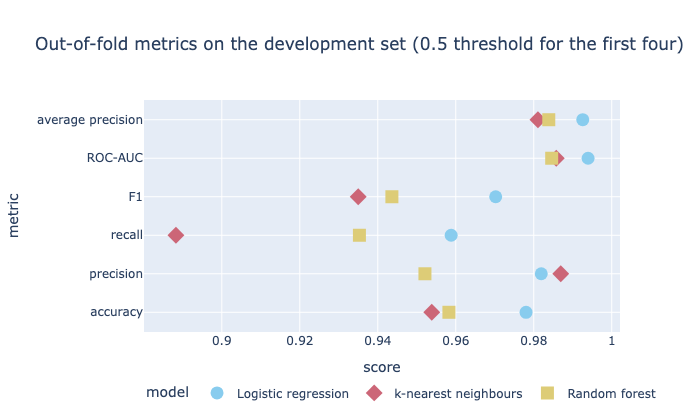

highest out-of-fold average precision: Logistic regression (0.993)


In [45]:
long_results = cv_results.reset_index().melt(id_vars="model", var_name="metric", value_name="score")
fig_compare = px.scatter(long_results, x="score", y="metric", color="model", color_discrete_map=MODEL_COLORS,
                         symbol="model", hover_data={"score": ":.3f"},
                         title="Out-of-fold metrics on the development set (0.5 threshold for the first four)")
fig_compare.update_traces(marker_size=13)
fig_compare.update_layout(height=420, legend=dict(orientation="h", y=-0.2))
fig_compare.show()

best_model_name = cv_results["average precision"].idxmax()
print(f"highest out-of-fold average precision: {best_model_name} ({cv_results.loc[best_model_name, 'average precision']:.3f})")

### Step 5 — ROC and precision-recall curves side by side

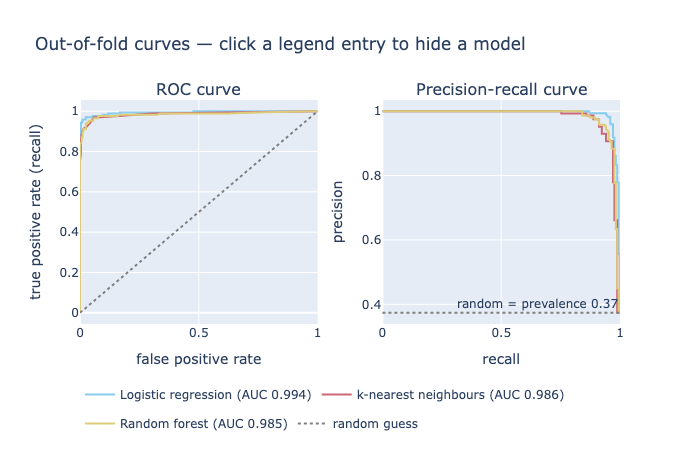

In [46]:
fig_curves = make_subplots(rows=1, cols=2, subplot_titles=("ROC curve", "Precision-recall curve"), horizontal_spacing=0.12)
for name, proba in oof_proba.items():
    fpr, tpr, _ = roc_curve(y_dev, proba)
    prec, rec, _ = precision_recall_curve(y_dev, proba)
    color = MODEL_COLORS[name]
    fig_curves.add_trace(go.Scatter(x=fpr, y=tpr, mode="lines", line_color=color, legendgroup=name,
                                    name=f"{name} (AUC {cv_results.loc[name, 'ROC-AUC']:.3f})"), row=1, col=1)
    fig_curves.add_trace(go.Scatter(x=rec, y=prec, mode="lines", line_color=color, legendgroup=name, showlegend=False,
                                    line_shape="hv"), row=1, col=2)

fig_curves.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode="lines", line=dict(dash="dot", color="grey"), name="random guess"), row=1, col=1)
fig_curves.add_hline(y=y_dev.mean(), line_dash="dot", line_color="grey", row=1, col=2,
                     annotation_text=f"random = prevalence {y_dev.mean():.2f}")
fig_curves.update_xaxes(title_text="false positive rate", row=1, col=1)
fig_curves.update_yaxes(title_text="true positive rate (recall)", row=1, col=1)
fig_curves.update_xaxes(title_text="recall", row=1, col=2)
fig_curves.update_yaxes(title_text="precision", row=1, col=2)
fig_curves.update_layout(height=450, title="Out-of-fold curves — click a legend entry to hide a model",
                         legend=dict(orientation="h", y=-0.25))
fig_curves.show()

### Step 6 — Choose the operating point with a threshold slider

Missing a malignant tumour (false negative) is far worse than an extra biopsy (false positive), so the requirement is **recall ≥ 95%**. Among thresholds meeting it we take the **highest**, because it has the fewest false alarms (recall can only fall as the threshold rises).

First, *why not a single validation split?* Pick the threshold on 5 different random 75/25 splits of the development set and watch the answer move.

In [47]:
TARGET_RECALL = 0.95
thresholds = np.round(np.arange(0.02, 0.99, 0.02), 2)


def highest_threshold_meeting(y_true, proba, target=TARGET_RECALL):
    _, rec = pr_at_thresholds(y_true, proba, thresholds)
    return float(thresholds[np.flatnonzero(rec >= target).max()])


single_split_choices = []
for seed in range(5):
    X_a, X_b, y_a, y_b = train_test_split(X_dev, y_dev, test_size=0.25, stratify=y_dev, random_state=seed)
    proba_b = clone(models[best_model_name]).fit(X_a, y_a).predict_proba(X_b)[:, 1]
    single_split_choices.append(highest_threshold_meeting(y_b.to_numpy(), proba_b))

chosen_threshold = highest_threshold_meeting(y_dev.to_numpy(), oof_proba[best_model_name])
print(f"chosen on 5 single validation splits ({int(y_b.sum())} malignant each): {single_split_choices}"
      f" → spread {max(single_split_choices) - min(single_split_choices):.2f}")
print(f"chosen on out-of-fold predictions (all {int(y_dev.sum())} malignant): {chosen_threshold:.2f}")

chosen on 5 single validation splits (43 malignant each): [0.66, 0.86, 0.64, 0.3, 0.92] → spread 0.62
chosen on out-of-fold predictions (all 170 malignant): 0.54


at 0.54: out-of-fold precision 0.982, recall 0.953, F1 0.967 | TP FP FN TN = [162, 3, 8, 282]


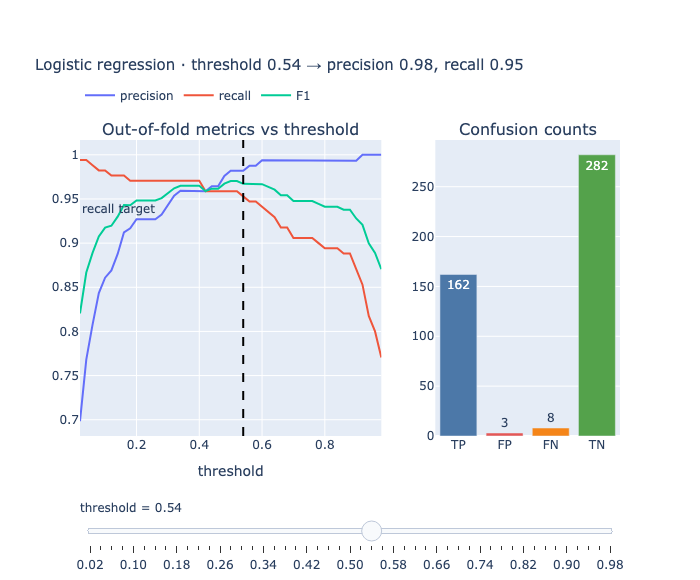

In [48]:
proba_dev = oof_proba[best_model_name]
y_dev_arr = y_dev.to_numpy()
precision_t, recall_t = pr_at_thresholds(y_dev_arr, proba_dev, thresholds)
f1_t = np.divide(2 * precision_t * recall_t, precision_t + recall_t, out=np.zeros_like(precision_t), where=(precision_t + recall_t) > 0)
pred_matrix = proba_dev[None, :] >= thresholds[:, None]
counts = np.stack([(pred_matrix & (y_dev_arr == 1)).sum(1), (pred_matrix & (y_dev_arr == 0)).sum(1),
                   (~pred_matrix & (y_dev_arr == 1)).sum(1), (~pred_matrix & (y_dev_arr == 0)).sum(1)], axis=1)   # TP FP FN TN
chosen = int(np.flatnonzero(np.isclose(thresholds, chosen_threshold))[0])
print(f"at {chosen_threshold:.2f}: out-of-fold precision {precision_t[chosen]:.3f}, recall {recall_t[chosen]:.3f}, "
      f"F1 {f1_t[chosen]:.3f} | TP FP FN TN = {counts[chosen].tolist()}")


def marker_line(t):
    return dict(type="line", x0=t, x1=t, y0=0, y1=1, xref="x", yref="y domain", line=dict(dash="dash", color="black"))


def step_title(i):
    return f"{best_model_name} · threshold {thresholds[i]:.2f} → precision {precision_t[i]:.2f}, recall {recall_t[i]:.2f}"


fig_threshold = make_subplots(rows=1, cols=2, column_widths=[0.62, 0.38],
                              subplot_titles=("Out-of-fold metrics vs threshold", "Confusion counts"))
for label, values in [("precision", precision_t), ("recall", recall_t), ("F1", f1_t)]:
    fig_threshold.add_trace(go.Scatter(x=thresholds, y=values, mode="lines", name=label), row=1, col=1)
fig_threshold.add_hline(y=TARGET_RECALL, line_dash="dot", line_color="grey", row=1, col=1,
                        annotation_text="recall target", annotation_position="bottom left")
fig_threshold.add_trace(go.Bar(x=["TP", "FP", "FN", "TN"], y=counts[chosen].tolist(), text=counts[chosen].tolist(),
                               marker_color=["#4C78A8", "#E45756", "#F58518", "#54A24B"], showlegend=False), row=1, col=2)

bar_index = len(fig_threshold.data) - 1
steps = [dict(label=f"{t:.2f}", method="update",
              args=[{"y": [counts[i].tolist()], "text": [counts[i].tolist()]},                       # trace changes…
                    {"shapes": [marker_line(float(t))], "title.text": step_title(i)},                # …layout changes…
                    [bar_index]])                                                                     # …applied to the bar trace only
         for i, t in enumerate(thresholds)]
fig_threshold.update_layout(
    shapes=[marker_line(chosen_threshold)], title=dict(text=step_title(chosen), font_size=15), height=580,
    margin=dict(t=140), legend=dict(orientation="h", x=0, y=1.2),
    sliders=[dict(active=chosen, steps=steps, currentvalue={"prefix": "threshold = "}, pad={"t": 60})],
)
fig_threshold.update_xaxes(title_text="threshold", row=1, col=1)
fig_threshold.show()

### Step 7 — Refit on all development data, touch the test set once, export

With only ~42 malignant tumours in the test set, one missed case moves recall by more than 2 points — so we report a **95% confidence interval** (Wilson method) instead of a bare number.

In [49]:
final_model = clone(models[best_model_name]).fit(X_dev, y_dev)
proba_test = final_model.predict_proba(X_test)[:, 1]
y_test_arr = y_test.to_numpy()
n_malignant = int(y_test_arr.sum())

report = {}
for label, t in [("default 0.50", 0.5), (f"chosen {chosen_threshold:.2f}", chosen_threshold)]:
    pred = proba_test >= t
    tp, fn, fp = int((pred & (y_test_arr == 1)).sum()), int((~pred & (y_test_arr == 1)).sum()), int((pred & (y_test_arr == 0)).sum())
    ci = binomtest(tp, n_malignant).proportion_ci(confidence_level=0.95, method="wilson")
    report[label] = {"precision": tp / max(tp + fp, 1), "recall": tp / n_malignant, "recall 95% CI": f"{ci.low:.3f}–{ci.high:.3f}",
                     "missed malignant (FN)": fn, "false alarms (FP)": fp}
test_report = pd.DataFrame(report).T
print(f"TEST set ({len(y_test_arr)} tumours, {n_malignant} malignant) — {best_model_name}")
print(test_report.to_string(float_format=lambda v: f"{v:.3f}"))

chosen_row = test_report.iloc[1]
ci_high = float(chosen_row["recall 95% CI"].split("–")[1])
if chosen_row["recall"] >= TARGET_RECALL:
    print(f"\n✅ recall target {TARGET_RECALL:.0%} met on the test set")
elif ci_high >= TARGET_RECALL:
    print(f"\n⚠️ test recall {chosen_row['recall']:.3f} is below {TARGET_RECALL:.0%}, but the target is inside the confidence interval —"
          f" {n_malignant} positives are too few to tell them apart. Say so, and gather more labelled cases before promising 95%.")
else:
    print(f"\n❌ test recall {chosen_row['recall']:.3f} is clearly below the {TARGET_RECALL:.0%} target — revisit the model or threshold.")

TEST set (114 tumours, 42 malignant) — Logistic regression
             precision recall recall 95% CI missed malignant (FN) false alarms (FP)
default 0.50     0.975  0.929   0.810–0.975                     3                 1
chosen 0.54      1.000  0.929   0.810–0.975                     3                 0

⚠️ test recall 0.929 is below 95%, but the target is inside the confidence interval — 42 positives are too few to tell them apart. Say so, and gather more labelled cases before promising 95%.


In [50]:
dashboard_path = OUTPUT_DIR / "model_dashboard.html"
sections = [fig_compare, fig_curves, fig_threshold]
body = "".join(f.to_html(full_html=False, include_plotlyjs=("cdn" if i == 0 else False)) for i, f in enumerate(sections))
dashboard_path.write_text(
    "<!doctype html><html><head><meta charset='utf-8'><title>Breast cancer model dashboard</title></head><body>"
    f"<h1>Malignant-tumour classifiers — development-set dashboard</h1>"
    f"<p>Chosen: {best_model_name}, threshold {chosen_threshold:.2f} (out-of-fold recall target {TARGET_RECALL:.0%}).</p>"
    f"{body}</body></html>"
)
print(f"dashboard saved → {dashboard_path} ({dashboard_path.stat().st_size / 1024:.0f} KB) — open it in any browser")

dashboard saved → _outputs/model_dashboard.html (66 KB) — open it in any browser


**Stretch goals**
1. Add a **cost** trace to the threshold chart: `cost = 10 × FN + 1 × FP` and mark its minimum. How far is it from the recall-target threshold?
2. Add a **calibration** (reliability) curve per model — do the "probabilities" mean what they say? (Module 03 covers calibration.)
3. Replace "highest threshold meeting the target" with a safety margin, e.g. require the *lower* end of a bootstrap interval of out-of-fold recall to reach 95%.
4. Rebuild the dashboard in **Dash** or **Streamlit** so the threshold can be typed in freely instead of chosen from precomputed steps.

### 🗣️ How to talk about this in an interview
- "I locked away a stratified 20% test set, compared three models with **5-fold out-of-fold predictions** on the rest, and touched the test set once at the end."
- "Malignant is the positive class — scikit-learn encodes it as 0, so I flipped the labels explicitly; getting that wrong silently swaps what precision and recall mean."
- "I showed that choosing a threshold on one small validation split is unstable — it moved a lot across random splits — so I chose it on out-of-fold predictions that use every development row."
- "Stakeholders picked the operating point with a **threshold slider** showing precision, recall, and raw confusion counts; the dashboard is a single static HTML file because every slider state is precomputed with a vectorized `(thresholds × samples)` matrix."
- "On the test set I reported recall **with a confidence interval**, because 42 positives can't distinguish 93% from 95% recall — that honesty matters more than a single number."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. When would you use Plotly instead of Matplotlib or Seaborn?**

<details><summary>Show answer</summary>

- **30-second answer:** When the audience needs to *explore* — hover for exact values, zoom, toggle series — or when the chart lives in a web page or dashboard (Dash, Streamlit). For papers, slides, and fast EDA, Matplotlib/Seaborn are lighter and fully static.
- **Go deeper:** Plotly output is JSON rendered by JavaScript, so it needs a browser (or kaleido + Chrome for images). Large interactive notebooks get heavy; static images are better for version control and PDFs.
- **❌ Common wrong answer:** "Plotly is always better because it's interactive." Interactivity adds weight and can hide the one message a static chart should make obvious.

</details>

**Q2. What is a Plotly figure internally, and how does that affect what you can do with it?**

<details><summary>Show answer</summary>

- **30-second answer:** A JSON-serializable object with `data` (a list of traces), `layout`, and optional `frames`. Python builds the JSON; plotly.js draws it.
- **Go deeper:** Because it's data, the same figure can be saved (`to_json`), embedded in HTML, returned from an API, rendered by Dash, or tested (`assert fig.layout.xaxis.type == "log"`). Controls like sliders can only replay **stored** states — no Python runs when a viewer drags them.
- **❌ Common wrong answer:** "Plotly makes images in Python" — images are an export step through kaleido.

</details>

**Q3. Plotly Express or Graph Objects — how do you choose?**

<details><summary>Show answer</summary>

- **30-second answer:** Start with `px` for any chart that maps DataFrame columns to visual properties; switch to `go` (or add `go` traces to a `px` figure) for mixed trace types, subplots with different charts, or custom controls.
- **Go deeper:** `px` returns a `go.Figure`, so there is no lock-in. `px` also does helpful work: one trace per category, consistent colors, facets, hover templates, animation frames.
- **❌ Common wrong answer:** "`go` is the new API and `px` is deprecated." Both are current; `px` is built on `go`.

</details>

**Q4. How would you let a product manager pick a classification threshold?**

<details><summary>Show answer</summary>

- **30-second answer:** Show precision, recall (and ideally expected cost) versus threshold on **validation** data (or out-of-fold cross-validation predictions when data is small), plus the raw confusion counts, with a slider. Agree on the business constraint (e.g. recall ≥ 95%), pick the threshold that satisfies it on validation, then confirm once on the test set.
- **Go deeper:** Translate counts into business units ("12 extra manual reviews per 1,000 cases"). Re-check the threshold after deployment because class balance and score distributions drift.
- **❌ Common wrong answer:** "Use 0.5" or "choose the threshold with the best test-set F1" (that leaks the test set into the decision).

</details>

**Q5. How do you plot millions of points interactively?**

<details><summary>Show answer</summary>

- **30-second answer:** Don't send millions of SVG points to a browser. Aggregate (`px.density_heatmap`, hexbins, histograms), sample, or use WebGL traces (`go.Scattergl`, or `render_mode="webgl"` in `px.scatter`) which handle hundreds of thousands of points.
- **Go deeper:** For true big-data scatter use server-side rasterization (Datashader) and send an image. File size matters too: every point is serialized into the HTML/notebook.
- **❌ Common wrong answer:** "Plotly handles any size; just call `fig.show()`." The notebook or browser tab will freeze.

</details>

### 💻 Coding

**Q6. You have a DataFrame with one row per model and one column per metric. Plot a grouped comparison.**

<details><summary>Show answer</summary>

- **30-second answer:** Reshape to long ("tidy") form, then map columns: `long = df.reset_index().melt(id_vars="model", var_name="metric", value_name="score")`; `px.bar(long, x="metric", y="score", color="model", barmode="group")`.
- **Go deeper:** If values are all near 1, prefer a dot plot over bars with a truncated axis. Pin model colors with `color_discrete_map` so every chart in the report agrees.
- **❌ Common wrong answer:** Looping `add_trace` per column of a wide DataFrame when one `melt` + `px` call does it.

</details>

**Q7. How do dropdowns and sliders work in a Plotly figure?**

<details><summary>Show answer</summary>

- **30-second answer:** `layout.updatemenus` (buttons/dropdowns) and `layout.sliders` hold a list of buttons/steps; each has a `method` — `restyle` (trace props), `relayout` (layout props), `update` (both), or `animate` — and `args` describing the change.
- **Go deeper:** A common pattern is to add every trace up front and toggle `visible`. For `update`, a third element in `args` lists which trace indices to change. Everything is precomputed, so the file size grows with the number of states.
- **❌ Common wrong answer:** "The slider calls back into Python." That needs Dash/Streamlit/ipywidgets.

</details>

### 🐛 Debugging Scenarios

**Q8. Your bar chart of revenue by day looks striped and hover shows tiny numbers. What happened?**

<details><summary>Show answer</summary>

- **30-second answer:** `px.bar` was given raw transaction rows; it stacks one segment per row instead of summing. Aggregate first (`groupby(...).sum()`), or use `px.histogram(x="day", y="revenue", histfunc="sum")`.
- **Go deeper:** Check with `len(fig.data[0].x)` — it should equal the number of bars. Assert the plotted totals equal the source totals before sharing the chart.
- **❌ Common wrong answer:** "It's a rendering glitch; set `marker_line_width=0`." That hides the stripes but not the problem.

</details>

**Q9. Charts appear in your Jupyter notebook but are blank on GitHub and in a CI-generated report. How do you fix it?**

<details><summary>Show answer</summary>

- **30-second answer:** Plotly output is JavaScript; GitHub and many converters don't run it. Save a static snapshot too (`pio.renderers.default = "plotly_mimetype+png"`, or `fig.write_image`), or publish `write_html` files.
- **Go deeper:** Static export uses kaleido, which (from v1) needs Chrome/Chromium installed — in CI containers install Chromium or run `plotly_get_chrome`.
- **❌ Common wrong answer:** "Reinstall plotly" or "switch to `notebook` renderer" — the viewer still won't execute JavaScript.

</details>

**Q10. In your animated chart, some points disappear in later years. Why?**

<details><summary>Show answer</summary>

- **30-second answer:** Axis ranges are computed from the first frame and are not recomputed per frame. Set `range_x`/`range_y` to cover all frames.
- **Go deeper:** Also set `animation_group` so the same entity is tracked between frames; otherwise points are matched by row order and appear to jump between countries.
- **❌ Common wrong answer:** "Those rows have missing data."

</details>

**Q11. Your team's HTML model reports are 5 MB each and the repo is ballooning. What's going on?**

<details><summary>Show answer</summary>

- **30-second answer:** `write_html` embeds the whole plotly.js library by default. Use `include_plotlyjs="cdn"` (tiny files, needs internet) or `"directory"` (one shared `plotly.min.js` next to the reports).
- **Go deeper:** Also downsample data in the figure — every point is stored in the JSON. And don't commit generated reports; publish them as CI artifacts.
- **❌ Common wrong answer:** "Compress the HTML with gzip" — helps a bit but keeps a duplicate library per file.

</details>

### 🏗️ Design

**Q12. Design an internal dashboard to compare experiments and monitor a deployed classifier. What would you show and what would you build it with?**

<details><summary>Show answer</summary>

- **30-second answer:** Pages for (1) experiment comparison — metrics table + dot plot + ROC/PR curves per run; (2) operating point — threshold slider with cost and confusion counts; (3) monitoring — daily volume, score distribution drift, precision/recall on labelled feedback, per-segment facets. Use an experiment tracker (MLflow / W&B) for runs and Dash or Streamlit with Plotly charts for the custom views.
- **Go deeper:** Precompute aggregates in a scheduled job rather than querying raw predictions per page view; version the data behind each chart; add static PNG exports for weekly reports; keep colors and model names consistent.
- **❌ Common wrong answer:** A single accuracy line chart — it hides class imbalance, calibration drift, and segment failures.

</details>

## 🧪 Quick Quiz

Predict the output, then reveal.

**1.** `len(px.scatter(gap2007, x="gdpPercap", y="lifeExp", color="continent").data)`
<details><summary>Answer</summary>

`5` — Plotly Express creates one trace per color category (Africa, Americas, Asia, Europe, Oceania).
</details>

**2.** `len(px.bar(tips, x="day", y="total_bill").data[0].x)`
<details><summary>Answer</summary>

`244` — one bar segment per raw row. `px.bar` does not aggregate.
</details>

**3.** `len(px.scatter(gapminder, x="gdpPercap", y="lifeExp", animation_frame="year").frames)`
<details><summary>Answer</summary>

`12` — one frame per year from 1952 to 2007 in steps of 5.
</details>

**4.** After `fig = make_subplots(rows=2, cols=2)` and `fig.add_trace(go.Scatter(x=[1], y=[1]), row=2, col=1)`, what is `fig.data[0].xaxis`?
<details><summary>Answer</summary>

`'x3'` — subplots are numbered left-to-right, top-to-bottom, so (row 2, col 1) is the third x-axis.
</details>

**5.** Which renderer setting shows an interactive chart in JupyterLab **and** stores a static image GitHub can display?
(a) `"notebook"` (b) `"browser"` (c) `"plotly_mimetype+png"` (d) `"json"`
<details><summary>Answer</summary>

**(c)** — `+` combines renderers: `plotly_mimetype` for the interactive frontend, `png` for a static snapshot saved in the notebook.
</details>

## 📚 Resources

### 📖 Official Docs
- [Plotly Express in Python](https://plotly.com/python/plotly-express/) — the high-level API: one call per chart
- [Graph Objects in Python](https://plotly.com/python/graph-objects/) — the figure model underneath Plotly Express, for full control
- [Displaying Figures in Python](https://plotly.com/python/renderers/) — every renderer, and how to combine them
- [Static Image Export in Python](https://plotly.com/python/static-image-export/) — PNG/SVG/PDF with kaleido (and the Chrome requirement)
- [Interactive HTML Export in Python](https://plotly.com/python/interactive-html-export/) — `write_html` options, including `include_plotlyjs`
- [Sliders in Python](https://plotly.com/python/sliders/) and [Custom Buttons in Python](https://plotly.com/python/custom-buttons/) — the `restyle` / `relayout` / `update` methods

### 🎥 Videos
- [Charming Data — Getting Started With Plotly](https://www.youtube.com/watch?v=u4VOc4qE9LM) (8m25s) — a quick first look by Adam Schroeder (now at Plotly); watch before section 1 if you like video first
- [Charming Data — Introduction to Plotly Data Visualization](https://www.youtube.com/watch?v=_b2KXL0wHQg) (27m26s) — a slower beginner walkthrough of the common chart types
- [Plotly — Plotly Express & Dash](https://www.youtube.com/watch?v=DIk-y41djCQ) (42m38s) — official channel: from Plotly Express charts to a Dash app, the natural next step after the mini project

### 📄 Papers
- [Shneiderman (1996) — The Eyes Have It: A Task by Data Type Taxonomy for Information Visualizations](https://www.cs.umd.edu/~ben/papers/Shneiderman1996eyes.pdf) — the origin of "overview first, zoom and filter, then details-on-demand", the idea behind hover and zoom
- [Heer & Shneiderman (2012) — Interactive Dynamics for Visual Analysis](https://idl.cs.washington.edu/files/2012-InteractiveDynamics-CACM.pdf) — which interactions (filter, link, annotate) actually help analysis

### 📘 Books & Courses
- [Claus O. Wilke — Fundamentals of Data Visualization](https://clauswilke.com/dataviz/) — free online book on choosing honest, readable charts
- [Dash in 20 Minutes Tutorial](https://dash.plotly.com/tutorial) — wrap Plotly figures in a real web app with callbacks

### 🏋️ Practice
- [Kaggle Learn — Data Visualization](https://www.kaggle.com/learn/data-visualization) — short free exercises in the browser (uses Seaborn; redo them in Plotly Express)
- [Plotly Dash App Examples](https://plotly.com/examples/) — real dashboards with source code to study and adapt

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / rule |
|---|---|---|
| Figure | data + layout (+ frames) as JSON | `go.Figure`, `fig.data`, `fig.layout`, `fig.to_json()` |
| Plotly Express | one call from a tidy DataFrame | `px.scatter/line/bar/histogram/box/imshow(df, x=, y=, color=)` |
| Graph Objects | trace-by-trace control | `go.Figure()`, `add_trace(go.Scatter(...))`, `update_layout` |
| Aggregation | bars need one row per bar | `groupby(...).sum()` **before** `px.bar` |
| Hover | readable tooltips | `hover_name`, `hover_data={"col": ":,.0f"}`, `hovertemplate` |
| Facets | small multiples | `facet_col`, `facet_row`, `facet_col_wrap` |
| Animation | one frame per value | `animation_frame`, `animation_group`, **fix** `range_x/range_y` |
| Subplots | mix chart types | `make_subplots(rows, cols, specs=[[{"secondary_y": True}]])` |
| Styling | consistent look | `template="plotly_white"`, `update_traces`, `update_xaxes`, `add_hline` |
| Maps | color countries / plot points | `px.choropleth(locations="iso_alpha")`, `px.scatter_geo`, `px.scatter_map` |
| Renderers | what `fig.show()` emits | `pio.renderers.default = "plotly_mimetype+png"` |
| Export | share results | `write_html(include_plotlyjs="cdn")`, `write_image("f.png", scale=2)` |
| Controls | no-server interactivity | `updatemenus` / `sliders` with `restyle`, `relayout`, `update` |

## ➡️ What's Next

**[03 · Classical ML — ML Fundamentals From Scratch](../03_Classical_Machine_Learning/01_ML_Fundamentals_From_Scratch.ipynb)** — you just *visualized* precision, recall, ROC curves, and thresholds; next you'll build logistic regression, regularization, cross-validation, and every one of those metrics from scratch, so you can explain exactly what the charts mean in an interview.